In [1]:
# 1. Standard Python Libraries ---
import os                                     # Handles file paths and directory checks
os.environ["OMP_NUM_THREADS"]= "1"
os.environ["MKL_NUM_THREADS"]= "1"
os.environ["OPENBLAS_NUM_THREADS"]= "1"
os.environ["NUMEXPR_NUM_THREADS"]= "1"
os.environ["VECLIB_MAXIMUM_THREADS"]= "1"
import sys                                    # Access to system parameters and exit functions
import logging                                # Tracks events, errors, and status updates
import argparse                               # Manages input arguments (useful for script settings)
import pandas as pd                           # Data manipulation and analysis
import numpy as np
# 2. Math & Statistics ---

# import numpy as np                          # The core library for numerical operations and arrays
from scipy.stats import poisson, norm         # specific probability distributions for statistical analysis

# 3. Astronomy & Cosmology ---
from astropy import units as u                # Handles physical units (Mpc, km/s, degrees, etc.)
from astropy.cosmology import Planck18        # Pre-defined cosmology model (Planck 2015 parameters)
from astropy.cosmology import z_at_value      # Helper to convert distance back to redshift
from astropy.table import Table               # Efficient handling of data tables (like DataFrames)
from astropy.io import ascii                  # Reads/writes ASCII text files (common in astronomy)

# 4. MCMC & Fitting ---
import emcee                                  # The MCMC sampler (Markov Chain Monte Carlo)

# 5. Visualization & Plotting ---
import matplotlib.pyplot as plt               # Standard plotting library
import corner                                 # Specialized tool for making MCMC corner plots
import healpy as hp
from scipy.optimize import fsolve
from astropy.cosmology import Planck18        # Pre-defined cosmology model (Planck 2018 parameters)
from astropy.coordinates import SkyCoord      # Helper for astronomical coordinate transformations
import seaborn as sns                         # Statistical data visualization based on Matplotlib
#import cfod                                  # Importing the cfod module
import astropy.units as u

from scipy.stats import poisson, norm
import multiprocessing                        # Import the multiprocessing module
from scipy.integrate import quad
from scipy.special import gammaincc, gamma as gamma_func

In [2]:
from tqdm import tqdm

### **1. All Declarations**

In [3]:
# step 0. Configuration and Global Constants ---
cosmo = Planck18 # Using Planck 2015 cosmology

# Define the custom unit 'bursts'
bursts = u.def_unit('bursts', represents=u.dimensionless_unscaled)
u.add_enabled_units([bursts])

# Normalization constants for host galaxy properties (Milky Way-like values)
MW_SFR = 1.65 * u.M_sun / u.yr
MW_STELLAR_MASS = 6.0e10 * u.M_sun

# Default bandwidth for observations (e.g., CHIME, assumes 400-800 MHz)
DEFAULT_OBSERVATION_BANDWIDTH = (800 - 400) * u.MHz # 400 MHz


# Step 1: Define day-scale quantities
R_central_day = 525.0
R_sigma_day = np.sqrt(30.0**2 + ((142.0 + 131.0)/2.0)**2)

# Step 2: Convert to yearly
R_central_year = R_central_day * 365.25
R_sigma_year = R_sigma_day * 365.25

# Step 3: Convert to astropy units
CHIME_OBSERVED_RATE_REPORTED = (R_central_year * bursts) / u.yr
CHIME_OBSERVED_RATE_TOTAL_ERROR = (R_sigma_year * bursts) / u.yr

# Step 4: Convert to log10 space (AFTER defining above)
LOG10_R_MEAN = np.log10(R_central_year)
LOG10_R_SIGMA = R_sigma_year / (R_central_year * np.log(10))  # error propagation

# Step 5: Prior bounds
log10_R_min = LOG10_R_MEAN - 5 * LOG10_R_SIGMA
log10_R_max = LOG10_R_MEAN + 5 * LOG10_R_SIGMA 

PRIOR_BOUNDS = {
    'log10_R_all_sky': (log10_R_min, log10_R_max),
    'log10_E_min_pop': (30.0, 38.0),
    'gamma': (0.0, 3.5),
    'log10_E_star': (40.0, 43.0),
    'alpha': (-3.0, 1.0)
}

In [4]:
# Testing the code
print("1. Chime Observed Rate burst per year :" , CHIME_OBSERVED_RATE_REPORTED)
print("2. R mean testing :", LOG10_R_MEAN, LOG10_R_SIGMA)
print("3. Prior Bound :", PRIOR_BOUNDS)

1. Chime Observed Rate burst per year : 191756.25 bursts / yr
2. R mean testing : 5.282749528012292 0.11561152904015505
3. Prior Bound : {'log10_R_all_sky': (np.float64(4.704691882811517), np.float64(5.860807173213066)), 'log10_E_min_pop': (30.0, 38.0), 'gamma': (0.0, 3.5), 'log10_E_star': (40.0, 43.0), 'alpha': (-3.0, 1.0)}


### **2. Data File Loading Function definition**

In [5]:
def load_galaxy_catalog(file_path: str) -> Table:                             # Define function that takes file path (string) and returns an Astropy Table
    """
    Load and standardize a galaxy catalog for Bayesian analysis.

    This function reads a galaxy catalog file from the specified path using
    Astropy's ASCII reader and transforms the dataset into a clean, consistent
    format suitable for downstream statistical modeling (e.g., Bayesian inference,
    likelihood evaluation, or population studies).

    The function performs the following key operations:
    1. Safely loads the input catalog file with error handling.
    2. Verifies the presence of all required columns in the dataset.
    3. Renames columns from their original (often verbose or inconsistent)
       names into standardized, Python-friendly identifiers.
    4. Constructs a new Astropy Table containing only the required and renamed
       columns for further analysis.
    5. Logs detailed information about the loading process and column mappings
       for transparency and debugging.

    Parameters
    ----------
    file_path : str
        Path to the input galaxy catalog file.
        The file must be readable by `astropy.io.ascii.read` and contain
        all required columns listed in `column_mappings`.

    Returns
    -------
    Table
        An `astropy.table.Table` object containing the processed galaxy catalog.
        The table includes standardized column names such as:
        - galaxy_name : Identifier of the galaxy
        - ra_deg, dec_deg : Sky coordinates in degrees
        - d25_semi_major_arcmin, d25_semi_minor_arcmin : Galaxy size parameters
        - d25_pos_angle_deg : Orientation angle
        - inclination_angle_deg : Galaxy inclination
        - luminosity_distance_mpc : Distance to galaxy
        - log_sfr_hec : Logarithmic star formation rate
        - log10_stellar_mass_hec : Logarithmic stellar mass
        - total_observation_time_hr : Observation exposure time

    Raises
    ------
    FileNotFoundError
        If the specified file path does not exist.

    KeyError
        If any required column is missing from the input catalog.

    Exception
        For any other unexpected errors encountered during file reading.

    Notes
    -----
    - This function ensures consistency in column naming, which is critical
      for reproducible scientific analysis and integration with Bayesian models.
    - The output table is intentionally restricted to only the required fields
      to avoid ambiguity and reduce downstream processing complexity.
    - Logging is used extensively to aid debugging and provide traceability
      in large data-processing pipelines.

    """

    logging.info(f"Attempting to load galaxy catalog from '{file_path}'...")  # Log message to indicate loading has started

    try:                                                                      # Begin error-handling block to safely read file
        catalog = ascii.read(file_path)                                       # Read input file into Astropy Table (structured data format)

    except FileNotFoundError:                                                 # If file path is incorrect or file does not exist
        logging.error(f"Error: The file '{file_path}' was not found.")        # Log error message
        raise                                                                 # Re-raise error so main program stops execution properly

    except Exception as e:                                                    # Catch any other unexpected errors during file reading
        logging.error(f"Error reading file '{file_path}': {e}")               # Log detailed error message
        raise                                                                 # Re-raise exception for outer handling

    column_mappings = {                                                       # Dictionary to rename original column names to standardized names
        'Galaxy name': 'galaxy_name',                                         # Rename galaxy name column to clean Python-friendly format
        'RAJ2000 (deg)': 'ra_deg',                                            # Right Ascension in degrees (shortened for convenience)
        'DEJ2000 (deg)': 'dec_deg',                                           # Declination in degrees (used for sky position filtering)
        'D25 semi-major axis (arcmin)': 'd25_semi_major_arcmin',              # Galaxy major axis size
        'D25 semi-minor axis (arcmin)': 'd25_semi_minor_arcmin',              # Galaxy minor axis size
        'D25 positional angle, North-to-Northeast (deg)': 'd25_pos_angle_deg', # Orientation angle of galaxy ellipse
        'Inclination angle (deg)': 'inclination_angle_deg',                    # Inclination angle (important for selection cuts)
        'Luminosity distance (Mpc)': 'luminosity_distance_mpc',                # Distance to galaxy (used in astrophysical calculations)
        'logSFR_HEC': 'log_sfr_hec',                                           # Log star formation rate
        'logM_HEC': 'log10_stellar_mass_hec',                                  # Log stellar mass
        'mean_exposure_Hr': 'total_observation_time_hr',                       # Observation time (affects detection probability)
    }

    new_catalog_data = {}                                                      # Create empty dictionary to store cleaned/renamed data

    for original_col, new_col in column_mappings.items():                      # Loop over each mapping pair
        if original_col in catalog.colnames:                                   # Check if required column exists in input data
            new_catalog_data[new_col] = catalog[original_col]                  # Copy data into new dictionary with renamed column
        else:                                                                  # If required column is missing
            logging.error(                                                     # Log error message with details
                f"Required column '{original_col}' not found in the input catalog. "
                f"Available columns are: {catalog.colnames}"
            )
            raise KeyError(f"Missing column: {original_col}")                  # Raise error to stop execution (critical data missing)

    processed_catalog = Table(new_catalog_data)                                # Convert cleaned dictionary into Astropy Table

    logging.info(f"Successfully loaded catalog with {len(processed_catalog)} galaxies.")  # Log number of galaxies loaded
    logging.info("Renamed columns:")                                           # Log header for column mapping output
    for original, new in column_mappings.items():                              # Loop through mappings again for display
        logging.info(f"  '{original}' -> '{new}'")                             # Log each renaming for transparency/debugging

    return processed_catalog                                                   # Return final cleaned and standardized catalog for further analysis

##### **2.1 Test load_galaxy_catalog Data File Loading Function**

In [6]:
# --- Test script for load_galaxy_catalog ---                          # Section header indicating purpose of this block

# File path here                                                       # Define input file location
file_path = "LVG495.txt"  # Path to galaxy catalog file

try:                                                                  # Begin try block to safely execute function
    table = load_galaxy_catalog(file_path)                            # Call function to load and process catalog

    print("\n FUNCTION EXECUTED SUCCESSFULLY!\n")                     # Confirmation message if no error occurs

    # Show first 5 rows                                               # Display preview of dataset
    print(" First 5 rows of table:")                                  # Label for output section
    print(table[:5])                                                  # Print first five entries of the table

    # Show column names                                               # Display renamed column structure
    print("\n Column names after renaming:")                          # Label for column names output
    print(table.colnames)                                             # Print list of column names

    # Show number of galaxies                                         # Display dataset size
    print(f"\n Total galaxies loaded: {len(table)}")                  # Print total number of rows (galaxies)

except Exception as e:                                                # Catch any error during execution
    print("\nERROR OCCURRED:")                                        # Error message header
    print(e)                                                          # Print actual error details


 FUNCTION EXECUTED SUCCESSFULLY!

 First 5 rows of table:
galaxy_name   ra_deg  ... log10_stellar_mass_hec total_observation_time_hr
----------- --------- ... ---------------------- -------------------------
   UGC00092  2.508291 ...                 9.2305                     17.61
   UGC00313  7.858833 ...                 9.0369                     16.38
    NGC0145  7.940624 ...                 9.4395                     17.62
    NGC0278 13.017917 ...                10.2508                     18.15
    NGC0337 14.958512 ...                 10.118                     10.79

 Column names after renaming:
['galaxy_name', 'ra_deg', 'dec_deg', 'd25_semi_major_arcmin', 'd25_semi_minor_arcmin', 'd25_pos_angle_deg', 'inclination_angle_deg', 'luminosity_distance_mpc', 'log_sfr_hec', 'log10_stellar_mass_hec', 'total_observation_time_hr']

 Total galaxies loaded: 495


### **3. Core Helper Schechter Function**

In [7]:
def _schechter_function_integrand(E_norm, gamma):                                         # Defines Schechter integrand function (dimensionless energy input)
    """
    Computes the value of the Schechter-like integrand for a given normalized energy.

    This function represents the mathematical form of a Schechter distribution,
    which is widely used in astrophysics to describe quantities such as luminosity
    or energy distributions that follow a power-law behavior at low values and
    exhibit an exponential cutoff at high values.

    Parameters
    ----------
    E_norm : float or numpy.ndarray
        Dimensionless normalized energy defined as:
            E_norm = E / E_star
        where:
            - E is the energy (e.g., isotropic energy in erg),
            - E_star is the characteristic cutoff energy.
        This input can be a single value or an array of values. The function ensures
        numerical stability by enforcing a minimum value to avoid issues such as
        division by zero or invalid logarithms.

    gamma : float
        The power-law index (dimensionless).
        - Controls how steeply the function decreases at low energies.
        - Larger values of gamma lead to a steeper decline.
        - Physically, it determines how common low-energy vs high-energy events are.

    Returns
    -------
    float or numpy.ndarray
        The computed value(s) of the Schechter integrand:
            E_norm^(-gamma) * exp(-E_norm)
        - For small E_norm: dominated by the power-law term.
        - For large E_norm: dominated by the exponential cutoff.
        The output has the same shape as the input E_norm.

    Notes
    -----
    - The function applies a lower bound (1e-100) to E_norm to prevent numerical
      instability such as division by zero or overflow in exponentiation.
    - This function is typically used inside numerical integration routines
      (e.g., np.trapz, scipy.integrate) to compute total rates or probabilities.
    - The output is dimensionless since E_norm itself is dimensionless.
    """
    E_norm = np.maximum(E_norm, 1e-100)                                                   # Prevents zero/negative values to avoid numerical instability (log/div issues)
    return E_norm**(-gamma) * np.exp(-E_norm)                                             # Schechter form: power-law * exponential cutoff

In [8]:
def _integrate_schechter(E_min_iso: u.Quantity, E_star: u.Quantity, gamma: float, num_integration_points: int = 10000, method="trapz") -> u.Quantity:
#def _integrate_schechter(E_min_iso: u.Quantity, E_star: u.Quantity, gamma: float, num_integration_points: int = 10000) -> u.Quantity:
                                                                                          # Numerically integrates Schechter function from E_min to infinity
    """
    Numerically evaluates the integral of a Schechter-like energy distribution from a
    minimum energy threshold (E_min_iso) to infinity using a logarithmically spaced grid
    and the trapezoidal rule.

    This function is commonly used in astrophysical analyses to compute the cumulative
    contribution (e.g., rate, probability, or number density) of sources above a given
    energy threshold, assuming a Schechter functional form.

    Mathematical Form
    -----------------
    The function computes the following dimensionless integral:

        ∫_{E_min/E_star}^{∞} x^{-gamma} * exp(-x) dx

    where:
        x = E / E_star  (dimensionless normalized energy)

    Since the upper limit is infinity, it is approximated numerically by choosing a
    sufficiently large cutoff where the exponential term ensures negligible contribution.

    Parameters
    ----------
    E_min_iso : astropy.units.Quantity
        Minimum isotropic energy threshold (e.g., in erg).
        - Represents the lower bound of integration.
        - Must be strictly positive.
        - Physically, it defines the detection or selection threshold of events.

    E_star : astropy.units.Quantity
        Characteristic cutoff energy (e.g., in erg).
        - Defines where the exponential suppression becomes significant.
        - Must be strictly positive.
        - Used to normalize energies into a dimensionless form.

    gamma : float
        Power-law index (dimensionless).
        - Controls the slope of the distribution at low energies.
        - Larger values imply a steeper decline in the number of low-energy events.

    num_integration_points : int, optional (default = 10000)
        Number of grid points used in numerical integration.
        - Higher values increase accuracy but also computational cost.
        - Logarithmic spacing is used to efficiently handle wide dynamic ranges.

    Returns
    -------
    astropy.units.Quantity
        Dimensionless integral result (unit: dimensionless_unscaled).
        - Represents the total contribution of the Schechter function above E_min_iso.
        - If the computation fails (due to invalid inputs or numerical instability),
          the function returns:
              -np.inf * u.dimensionless_unscaled

    Numerical Method
    ----------------
    - The integration is performed using `numpy.trapz` (trapezoidal rule).
    - The integration grid is logarithmically spaced to accurately capture:
        * Power-law behavior at low energies
        * Rapid exponential decay at high energies
    - The upper integration limit is dynamically chosen to ensure the exponential
      cutoff is well covered.

    Validation and Stability Checks
    -------------------------------
    The function includes multiple safeguards:
    - Ensures E_star is positive (avoids invalid normalization).
    - Ensures normalized lower bound is positive.
    - Verifies that all computed integrand values are finite.
    - Rejects negative or non-finite integration results.
    - Returns -np.inf in case of failure to signal invalid likelihood computations.
    """

    if E_star.to_value(u.erg) <= 0:                                                       # Check if characteristic energy is physically valid
        return 0.0 * u.dimensionless_unscaled                                             # Return zero if invalid (prevents division errors)

    E_min_norm = (E_min_iso / E_star).to_value(u.dimensionless_unscaled)                  # Normalize energy (dimensionless)

    if E_min_norm <= 0:                                                                   # Ensure valid normalized lower bound
        return -np.inf * u.dimensionless_unscaled                                         # Return invalid result if non-physical

    x_max_norm = max(E_min_norm * 10, 1000.0)                                             # Set upper integration limit (ensures exponential decay coverage)

    if x_max_norm <= E_min_norm:                                                          # Safety check for bounds
        x_max_norm = E_min_norm + 1.0                                                     # Ensure upper bound > lower bound

    X_values = np.logspace(np.log10(E_min_norm), np.log10(x_max_norm), num=num_integration_points)
                                                                                          # Create logarithmically spaced grid (important for wide dynamic range)

    Y_values = _schechter_function_integrand(X_values, gamma)                             # Evaluate integrand at all grid points

    if not np.all(np.isfinite(Y_values)):                                                 # Check for NaN or infinite values
        return -np.inf * u.dimensionless_unscaled                                         # Return invalid if numerical instability occurs

    #integral_result = np.trapz(Y_values, X_values)                                       # Perform numerical integration using trapezoidal rule
    if method == "trapz":                                                                 # Use classic trapezoidal rule
        integral_result = np.trapz(Y_values, X_values)

    elif method == "trapezoid":                                                           # Use new NumPy method
        integral_result = np.trapezoid(Y_values, X_values)

    else:
        raise ValueError("method must be 'trapz' or 'trapezoid'")
    if not np.isfinite(integral_result) or integral_result < 0:                           # Validate result
        return -np.inf * u.dimensionless_unscaled                                         # Reject invalid or negative integrals

    return integral_result * u.dimensionless_unscaled                                     # Return dimensionless integral result

##### **3.2 Testing the _integrate_schechter function**









In [9]:
def sfrd(z: float) -> u.Quantity:                                                         # Cosmic Star Formation Rate Density function
    """
    Computes the Cosmic Star Formation Rate Density (SFRD) as a function of redshift.

    This function provides an empirical model for how the rate of star formation
    per unit volume of the Universe evolves with cosmic time (parameterized by redshift z).
    It is based on a widely used parametrization similar to the Madau & Dickinson (2014)
    formulation, which captures the observed rise and fall of star formation activity
    across cosmic history.

    Parameters
    ----------
    z : float
        Redshift (dimensionless).
        - Represents how far back in time we are observing the Universe.
        - z = 0 corresponds to the present-day Universe.
        - Higher z values correspond to earlier cosmic times (e.g., z ~ 2–3 is the peak of star formation).

    Returns
    -------
    astropy.units.Quantity
        Cosmic Star Formation Rate Density with units:
            M_sun / yr / Mpc^3
        (solar masses formed per year per cubic megaparsec)

        This value represents the average rate at which new stars are being formed
        in a unit volume of the Universe at a given redshift.

    Physical Meaning
    ----------------
    - At low redshift (z ≈ 0): Star formation is relatively low (Universe is aging).
    - At intermediate redshift (z ≈ 2–3): Star formation reaches its peak ("cosmic noon").
    - At high redshift (z > 5): Star formation declines due to early galaxy formation limits.

    Mathematical Form
    -----------------
    The function follows an empirical double power-law form:

        SFRD(z) ∝ (1 + z)^a / [1 + ((1 + z)/b)^c]

    where:
        - The numerator describes the rise in star formation at early times.
        - The denominator introduces a turnover and decline at high redshift.

    Numerical Behavior
    ------------------
    - Smooth and continuous over all valid redshift values (z ≥ 0).
    - Always returns a positive finite value for physical inputs.
    - The function is unit-consistent using astropy.units.
    """

    sfrd_val = 0.015 * (1 + z)**2.7 / (1 + ((1 + z) / 2.9)**5.6) * (u.M_sun / u.yr / u.Mpc**3)
                                                                                          # Empirical Madau & Dickinson-like formula for cosmic SFR evolution
    return sfrd_val.to(u.M_sun / u.yr / u.Mpc**3)                                         # Ensure correct units

##### **3.3 Testing the sfrd function**


In [10]:
def total_stellar_mass_density(z, R=0.27):                                                # Computes Cosmic Stellar Mass Density (CSMD)
    """
    Computes the Cosmic Stellar Mass Density (CSMD) at a given redshift.

    This function estimates the total amount of stellar mass per unit comoving volume
    in the Universe at redshift z by integrating the Cosmic Star Formation Rate Density (SFRD)
    over cosmic time from redshift z to the early Universe (z → ∞).

    The calculation accounts for cosmological time dilation and stellar mass recycling,
    making it a physically motivated estimate of how much stellar mass has accumulated
    over the history of the Universe up to a given epoch.

    Parameters
    ----------
    z : float
        Redshift (dimensionless).
        - Defines the epoch at which the stellar mass density is evaluated.
        - z = 0 corresponds to the present-day Universe.
        - Higher z corresponds to earlier cosmic times.

    R : float, optional (default = 0.27)
        Recycling fraction (dimensionless).
        - Represents the fraction of stellar mass returned to the interstellar medium
          through processes such as supernovae and stellar winds.
        - The factor (1 - R) gives the fraction of mass that remains locked in stars.

    Returns
    -------
    astropy.units.Quantity
        Cosmic Stellar Mass Density with units:
            M_sun / Mpc^3

        This represents the total stellar mass per unit comoving volume at redshift z.

    Mathematical Description
    ------------------------
    The function computes:

        CSMD(z) = (1 - R) * ∫_{z}^{∞} [ SFRD(z') / ((1 + z') * H(z')) ] dz'

    where:
        - SFRD(z') is the star formation rate density,
        - H(z') is the Hubble parameter,
        - (1 + z') accounts for cosmological time dilation (dt/dz relation).

    The final result is further normalized and scaled to match observational conventions.

    Numerical Method
    ----------------
    - Integration is performed using `scipy.integrate.quad`, an adaptive quadrature method.
    - The upper limit is set to infinity (np.inf), approximating the early Universe.
    - High precision tolerances (epsrel, epsabs) ensure accurate results.
    - The integrand is evaluated in unitless form for computational efficiency.

    Physical Interpretation
    -----------------------
    - At high redshift (early Universe): CSMD is low (few stars formed).
    - At low redshift (present day): CSMD is high (stars accumulated over time).
    - The function effectively "adds up" all past star formation, correcting for mass loss.
    """

    integrand = lambda z_prime: sfrd(z_prime).value / (                                   # Define integrand function over redshift
        (1 + z_prime) * cosmo.H(z_prime).to(u.yr**-1).value                               # Includes cosmological time dilation factor
    )
    integral_value, _ = quad(                                                             # Perform numerical integration from z to infinity
        integrand, z, np.inf,                                                             # Limits of integration
        limit=1000, epsrel=1e-8, epsabs=1e-10                                             # High precision settings
    )

    csmd = (1 - R) * integral_value                                                       # Apply recycling fraction correction (stellar mass loss)

    return (csmd / 6.08e10) / (1 + z) * (u.M_sun / u.Mpc**3)
    # return csmd*(u.M_sun / u.Mpc**3)

##### **3.4 Testing the total_stellar_mass_density function**



In [11]:
# Normalize and convert into proper units (accounts for cosmic expansion)
def get_differential_comoving_volume(z: float) -> u.Quantity:                             # Computes dV/dz/dOmega
    """
    Calculates the differential comoving volume dVc/dz/dOmega at redshift z.
    Returns: astropy.units.Quantity in Mpc^3 / sr.
    """
    return cosmo.differential_comoving_volume(z).to(u.Mpc**3 / u.sr)

##### **3.5 Testing the get_differential_comoving_volume function**

In [12]:
# Uses cosmology model to compute volume element
def _convert_fluence_to_isotropic_energy_with_bandwidth(
        fluence_Jy_ms: u.Quantity,                                                        # Observed fluence
        z: float,                                                                         # Redshift
        observation_bandwidth: u.Quantity,                                                # Telescope bandwidth
        alpha: float) -> u.Quantity:                                                      # Spectral index

    """
    Converts observed radio fluence into isotropic-equivalent energy (E_iso)
    while accounting for observational bandwidth and spectral index corrections.

    This function transforms the measured fluence of a transient source (e.g., FRBs)
    into the total isotropic energy emitted by the source, assuming the emission is
    radiated uniformly in all directions. It incorporates cosmological effects such as
    luminosity distance and redshift corrections, as well as spectral dependence.

    Parameters
    ----------
    fluence_Jy_ms : astropy.units.Quantity
        Observed fluence of the source in units of Jansky milliseconds (Jy ms).
        - Represents the time-integrated flux density.
        - Must carry appropriate units for conversion to physical energy.

    z : float
        Redshift of the source (dimensionless).
        - Determines cosmological distance and time dilation.
        - Affects both luminosity distance and spectral correction factors.

    observation_bandwidth : astropy.units.Quantity
        Bandwidth of the observing instrument (e.g., MHz or Hz).
        - Used to convert spectral fluence (per Hz) into total fluence.
        - Larger bandwidth → higher total measured energy.

    alpha : float
        Spectral index (dimensionless).
        - Defines how flux density scales with frequency: S(ν) ∝ ν^α
        - Influences the redshift correction factor (K-correction).
        - Typical values depend on source population (e.g., FRBs).

    Returns
    -------
    astropy.units.Quantity
        Isotropic-equivalent energy (E_iso) in units of erg.

        - Represents the total energy the source would emit if radiation
          were distributed uniformly in all directions.
        - If numerical instability occurs (invalid redshift term),
          returns np.inf * u.erg.

    Mathematical Description
    ------------------------
    The isotropic energy is computed as:

        E_iso = (4π D_L^2 * F_total) / (1 + z)^(2 + α)

    where:
        - D_L is the luminosity distance,
        - F_total is the fluence integrated over bandwidth,
        - (1 + z)^(2 + α) accounts for cosmological time dilation and
          spectral (K-correction) effects.

    Step-by-Step Process
    --------------------
    1. Convert fluence from Jy ms to physical units (erg/cm²/Hz).
    2. Multiply by observing bandwidth → total energy fluence (erg/cm²).
    3. Compute luminosity distance D_L using cosmology.
    4. Apply redshift and spectral correction factor.
    5. Scale by 4π D_L² to obtain isotropic energy.

    Physical Interpretation
    -----------------------
    - Larger fluence → higher inferred energy.
    - Larger distance (higher z) → significantly larger intrinsic energy.
    - Spectral index modifies how observed energy maps to emitted energy.
    - Bandwidth determines how much of the spectrum is captured.
    """

    fluence_erg_cm2_Hz = fluence_Jy_ms.to(u.erg / (u.cm**2 * u.Hz))
                                                                                          # Convert fluence to energy units per Hz
    D_L = cosmo.luminosity_distance(z).to(u.cm)                                           # Compute luminosity distance
    total_fluence_erg_cm2 = (fluence_erg_cm2_Hz * observation_bandwidth).to(u.erg / u.cm**2)
                                                                                          # Multiply by bandwidth to get total energy fluence
    redshift_term = (1 + z)**(2 + alpha)                                                  # Apply cosmological + spectral correction
    if not np.isfinite(redshift_term) or redshift_term <= 0:                              # Validate correction factor
        return np.inf * u.erg                                                             # Return invalid if unstable
    E_iso = (4 * np.pi * D_L**2 * total_fluence_erg_cm2 / redshift_term).to(u.erg)
                                                                                          # Convert fluence → isotropic energy using luminosity distance
    return E_iso                                                                          # Return isotropic equivalent energy

##### **3.6 Testing the _convert_fluence_to_isotropic_energy_with_bandwidth function**

In [13]:
def _get_effective_minimum_energy(
        z: float,
        fluence_threshold_Jy_ms: u.Quantity,
        observation_bandwidth: u.Quantity,
        E_min_population: u.Quantity,
        alpha: float) -> u.Quantity:                                                  # Function to compute effective minimum energy

    """
    Computes the effective minimum detectable isotropic energy (E_min,eff) at a given redshift.

    This function determines the lowest intrinsic (isotropic-equivalent) energy that can be
    observed at redshift z by combining two constraints:
    1. Instrumental detection threshold (based on fluence sensitivity)
    2. Intrinsic population cutoff (minimum energy of the source population)

    The effective minimum energy is defined as the maximum of these two limits:

        E_min,eff = max(E_min_population, E_min_from_fluence)

    Parameters
    ----------
    z : float
        Redshift (dimensionless).
        - Determines cosmological distance and energy scaling.

    fluence_threshold_Jy_ms : astropy.units.Quantity
        Detection threshold in Jy ms (instrument sensitivity limit).

    observation_bandwidth : astropy.units.Quantity
        Telescope bandwidth used to convert fluence into total energy.

    E_min_population : astropy.units.Quantity
        Intrinsic minimum energy cutoff of the population (in erg).

    alpha : float
        Spectral index used in K-correction.

    Returns
    -------
    astropy.units.Quantity
        Effective minimum isotropic energy in erg.

    Notes
    -----
    - Combines observational selection effects and intrinsic population limits.
    - Returns infinity if numerical instability occurs in fluence conversion.
    """

    E_min_from_fluence = _convert_fluence_to_isotropic_energy_with_bandwidth(   # Convert fluence threshold → isotropic energy
        fluence_threshold_Jy_ms,                                                # Input fluence threshold
        z,                                                                      # Redshift
        observation_bandwidth,                                                  # Bandwidth
        alpha                                                                   # Spectral index
    )

    if not np.isfinite(E_min_from_fluence.value):                               # Check if result is valid (finite)
        return np.inf * u.erg                                                   # Return infinity if unstable

    effective_E_min = max(                                                      # Take maximum of two limits
        E_min_population.to_value(u.erg),                                       # Population minimum energy
        E_min_from_fluence.to_value(u.erg)                                      # Detection-based minimum energy
    ) * u.erg                                                                   # Convert back to quantity

    return effective_E_min                                                      # Return effective minimum energy

##### **3.7 Testing the _get_effective_minimum_energy function**




### **4. Main Rate Model Functions**

In [14]:
# --- 3. Main Rate Model Functions ---                                    # Section for main FRB rate models

def all_sky_rate_model(params: tuple,                                     # Function to compute total FRB rate over full sky
                       global_fluence_threshold_Jy_ms: u.Quantity,         # Detection threshold (instrument sensitivity)
                       galaxy_property_value: u.Quantity,
                       model_property_type: str = 'sfr',                  # Choose scaling: 'sfr' or 'stellar mass'
                       z_max_integration: float = 2.5,                    # Maximum redshift for integration
                       num_redshift_points: int = 100,                    # Number of integration grid points
                       global_observation_bandwidth: u.Quantity = DEFAULT_OBSERVATION_BANDWIDTH) -> u.Quantity:  # Telescope bandwidth

    """
    Computes the theoretical all-sky Fast Radio Burst (FRB) rate above a given fluence threshold.

    This function models the observable FRB rate by integrating contributions from all redshifts,
    incorporating cosmological effects, source population properties, detection thresholds,
    and energy distribution via a Schechter function.

    The model accounts for:
    - Cosmic evolution of source density (via SFR or stellar mass density)
    - Instrumental detection limits (fluence threshold and bandwidth)
    - Energy distribution of bursts (Schechter function)
    - Cosmological volume expansion and time dilation

    Parameters
    ----------
    params : tuple
        Model parameters:
        (log10_R_all_sky, log10_E_min_pop, gamma, log10_E_star, alpha)

        - log10_R_all_sky : float
            Logarithm (base 10) of the intrinsic all-sky FRB rate (bursts/year).

        - log10_E_min_pop : float
            Logarithm of the minimum intrinsic energy of the FRB population (erg).

        - gamma : float
            Power-law index of the Schechter energy distribution.

        - log10_E_star : float
            Logarithm of the characteristic cutoff energy (erg).

        - alpha : float
            Spectral index used in fluence-to-energy conversion.

    global_fluence_threshold_Jy_ms : astropy.units.Quantity
        Detection threshold of the observing instrument (Jy ms).
        - Defines the minimum observable fluence.
        - Determines selection effects and detectability.

    model_property_type : str, optional (default = 'sfr')
        Choice of cosmic scaling:
        - 'sfr' → scales with cosmic star formation rate density (SFRD)
        - otherwise → scales with cosmic stellar mass density (CSMD)

    z_max_integration : float, optional (default = 2.5)
        Maximum redshift for integration.
        - Defines how far into the Universe the model considers contributions.

    num_redshift_points : int, optional (default = 100)
        Number of grid points used in numerical integration over redshift.
        - Logarithmic spacing ensures accuracy across wide range.

    global_observation_bandwidth : astropy.units.Quantity
        Telescope bandwidth used in fluence-to-energy conversion.

    Returns
    -------
    astropy.units.Quantity
        Predicted all-sky FRB rate in units:
            bursts / yr

        - Represents the total number of detectable FRBs across the entire sky.
        - Returns -np.inf * bursts/yr if numerical instability occurs.

    Mathematical Description
    ------------------------
    The model computes:

        Rate = R_all_sky × ∫ [ ρ(z) × f_detect(E > E_th(z)) × (dV/dz) × (1 / (1 + z)) ] dz

    where:
        - ρ(z): Cosmic source density evolution (SFRD or CSMD)
        - f_detect: Fraction of bursts above detection threshold
        - dV/dz: Differential comoving volume element
        - (1 + z): Time dilation factor

    The detectable fraction is computed using the Schechter function:

        f_detect = ∫_{E_th(z)}^∞ φ(E) dE / ∫_{E_min}^∞ φ(E) dE

    Physical Interpretation
    -----------------------
    - At low redshift:
        More bursts are detectable due to lower energy thresholds.
    - At high redshift:
        Detection becomes harder due to cosmological dimming.
    - The total rate is a balance between:
        * Increasing volume (more sources)
        * Decreasing detectability (selection effects)

    """

    log10_R_all_sky, log10_E_min_pop, gamma, log10_E_star, alpha = params   # Unpack model parameters (log-scale + physics params)

    R_all_sky = (10**log10_R_all_sky) * bursts / u.yr                       # Convert log rate → physical rate (bursts/year)
    E_min_pop = (10**log10_E_min_pop) * u.erg                              # Minimum intrinsic energy of population
    E_star = (10**log10_E_star) * u.erg                                    # Characteristic energy scale

    redshifts = np.logspace(np.log10(1e-4), np.log10(z_max_integration), num_redshift_points)
                                                                            # Create redshift grid (log-spaced for accuracy)

    integrand_values = []                                                  # Store integrand values for numerical integration

    for z in redshifts:                                                    # Loop over each redshift

        if model_property_type == 'sfr':                                   # If model follows star formation rate
            cosmic_density = sfrd(z)                                       # Use cosmic SFR density
            normalization_factor = MW_SFR                                  # Normalize with Milky Way SFR
        else:                                                              # Otherwise use stellar mass scaling
            cosmic_density = total_stellar_mass_density(z)                 # Cosmic stellar mass density
            normalization_factor = MW_STELLAR_MASS                         # Normalize with Milky Way stellar mass



        density_ratio_per_volume = (cosmic_density / normalization_factor).to(1/u.Mpc**3)
                                                                            # Convert to number density per volume

        E_th = _get_effective_minimum_energy(                              # Compute minimum detectable energy at redshift z
            z,
            global_fluence_threshold_Jy_ms,
            global_observation_bandwidth,
            E_min_pop,
            alpha
        )

        numerator = _integrate_schechter(E_th, E_star, gamma)              # Integrate energy distribution above threshold
        denominator = _integrate_schechter(E_min_pop, E_star, gamma)       # Normalize by total population energy range

        if denominator.value <= 0:                                         # Check for invalid normalization
            return -np.inf * bursts/u.yr                                   # Return invalid result

        energy_fraction = numerator / denominator                          # Fraction of bursts above detection threshold

        dVc_dz_dOmega = get_differential_comoving_volume(z)                # Cosmological volume element

        term = (                                                           # Full integrand expression
            density_ratio_per_volume *                                     # Source density scaling
            energy_fraction *                                              # Detectable fraction
            dVc_dz_dOmega *                                                # Volume element
            (4 * np.pi * u.sr) /                                           # Convert per steradian → full sky
            (1 + z)                                                        # Cosmological time dilation correction
        )

        integrand_values.append(term)                                      # Store integrand value

    integral = np.trapezoid(integrand_values, redshifts)                   # Perform numerical integration over redshift

    predicted_rate = R_all_sky * integral                                  # Multiply by normalization rate
    ####
    property_ratio = (galaxy_property_value / normalization_factor).to_value()# Galaxy-to-MW scaling factor
    predicted_rate = R_all_sky * property_ratio * energy_fraction/integral
    ####

    print(f"R_all_sky is : {R_all_sky}")
    print(f'integral is : {integral}')
    print(f'predicted rate is : {predicted_rate}')

    return predicted_rate.to(bursts/u.yr)                                  # Return final predicted all-sky rate

In [15]:
# --- 3. Main Rate Model Functions ---                                    # Section for main FRB rate models

def z_integral(params: tuple,                                     # Function to compute total FRB rate over full sky
                       global_fluence_threshold_Jy_ms: u.Quantity,         # Detection threshold (instrument sensitivity)
                       model_property_type: str = 'sfr',                  # Choose scaling: 'sfr' or 'stellar mass'
                       z_max_integration: float = 2.5,                    # Maximum redshift for integration
                       num_redshift_points: int = 100,                    # Number of integration grid points
                       global_observation_bandwidth: u.Quantity = DEFAULT_OBSERVATION_BANDWIDTH) -> u.Quantity:  # Telescope bandwidth

    """
    Computes the theoretical all-sky Fast Radio Burst (FRB) rate above a given fluence threshold.

    This function models the observable FRB rate by integrating contributions from all redshifts,
    incorporating cosmological effects, source population properties, detection thresholds,
    and energy distribution via a Schechter function.

    The model accounts for:
    - Cosmic evolution of source density (via SFR or stellar mass density)
    - Instrumental detection limits (fluence threshold and bandwidth)
    - Energy distribution of bursts (Schechter function)
    - Cosmological volume expansion and time dilation

    Parameters
    ----------
    params : tuple
        Model parameters:
        (log10_R_all_sky, log10_E_min_pop, gamma, log10_E_star, alpha)

        - log10_R_all_sky : float
            Logarithm (base 10) of the intrinsic all-sky FRB rate (bursts/year).

        - log10_E_min_pop : float
            Logarithm of the minimum intrinsic energy of the FRB population (erg).

        - gamma : float
            Power-law index of the Schechter energy distribution.

        - log10_E_star : float
            Logarithm of the characteristic cutoff energy (erg).

        - alpha : float
            Spectral index used in fluence-to-energy conversion.

    global_fluence_threshold_Jy_ms : astropy.units.Quantity
        Detection threshold of the observing instrument (Jy ms).
        - Defines the minimum observable fluence.
        - Determines selection effects and detectability.

    model_property_type : str, optional (default = 'sfr')
        Choice of cosmic scaling:
        - 'sfr' → scales with cosmic star formation rate density (SFRD)
        - otherwise → scales with cosmic stellar mass density (CSMD)

    z_max_integration : float, optional (default = 2.5)
        Maximum redshift for integration.
        - Defines how far into the Universe the model considers contributions.

    num_redshift_points : int, optional (default = 100)
        Number of grid points used in numerical integration over redshift.
        - Logarithmic spacing ensures accuracy across wide range.

    global_observation_bandwidth : astropy.units.Quantity
        Telescope bandwidth used in fluence-to-energy conversion.

    Returns
    -------
    astropy.units.Quantity
        Predicted all-sky FRB rate in units:
            bursts / yr

        - Represents the total number of detectable FRBs across the entire sky.
        - Returns -np.inf * bursts/yr if numerical instability occurs.

    Mathematical Description
    ------------------------
    The model computes:

        Rate = R_all_sky × ∫ [ ρ(z) × f_detect(E > E_th(z)) × (dV/dz) × (1 / (1 + z)) ] dz

    where:
        - ρ(z): Cosmic source density evolution (SFRD or CSMD)
        - f_detect: Fraction of bursts above detection threshold
        - dV/dz: Differential comoving volume element
        - (1 + z): Time dilation factor

    The detectable fraction is computed using the Schechter function:

        f_detect = ∫_{E_th(z)}^∞ φ(E) dE / ∫_{E_min}^∞ φ(E) dE

    Physical Interpretation
    -----------------------
    - At low redshift:
        More bursts are detectable due to lower energy thresholds.
    - At high redshift:
        Detection becomes harder due to cosmological dimming.
    - The total rate is a balance between:
        * Increasing volume (more sources)
        * Decreasing detectability (selection effects)

    """

    log10_R_all_sky , log10_E_min_pop, gamma, log10_E_star, alpha = params   # Unpack model parameters (log-scale + physics params)
    # log10_E_min_pop  = 30
    R_all_sky = (10**log10_R_all_sky) * bursts / u.yr                       # Convert log rate → physical rate (bursts/year)
    E_min_pop = (10**log10_E_min_pop) * u.erg                              # Minimum intrinsic energy of population
    E_star = (10**log10_E_star) * u.erg                                    # Characteristic energy scale

    redshifts = np.logspace(np.log10(1e-4), np.log10(z_max_integration), num_redshift_points)
                                                                            # Create redshift grid (log-spaced for accuracy)

    integrand_values = np.zeros(len(redshifts))                                                  # Store integrand values for numerical integration

    for i in range(len(redshifts)):                                                    # Loop over each redshift
        z = redshifts[i]

        if model_property_type == 'sfr':                                   # If model follows star formation rate
            cosmic_density = sfrd(z)                                       # Use cosmic SFR density
            normalization_factor = MW_SFR                                  # Normalize with Milky Way SFR
        else:                                                              # Otherwise use stellar mass scaling
            cosmic_density = total_stellar_mass_density(z)                 # Cosmic stellar mass density
            normalization_factor = MW_STELLAR_MASS                         # Normalize with Milky Way stellar mass



        density_ratio_per_volume = (cosmic_density / normalization_factor).to(1/u.Mpc**3)
                                                                            # Convert to number density per volume

        E_th = _get_effective_minimum_energy(                              # Compute minimum detectable energy at redshift z
            z,
            global_fluence_threshold_Jy_ms,
            global_observation_bandwidth,
            E_min_pop,
            alpha
        )

        numerator = _integrate_schechter(E_th, E_star, gamma)              # Integrate energy distribution above threshold
        denominator = _integrate_schechter(E_min_pop, E_star, gamma)       # Normalize by total population energy range

        if denominator.value <= 0:                                         # Check for invalid normalization
            return -np.inf * bursts/u.yr                                   # Return invalid result

        energy_fraction = numerator / denominator                          # Fraction of bursts above detection threshold

        dVc_dz_dOmega = get_differential_comoving_volume(z)                # Cosmological volume element

        term = (                                                           # Full integrand expression
            density_ratio_per_volume *                                     # Source density scaling
            energy_fraction *                                              # Detectable fraction
            dVc_dz_dOmega *                                                # Volume element
            (4 * np.pi * u.sr) /                                           # Convert per steradian → full sky
            (1 + z)                                                        # Cosmological time dilation correction
        )

        integrand_values[i] = term                                      # Store integrand value

    integral = np.trapezoid(integrand_values, redshifts)                   # Perform numerical integration over redshift

    return integral                                  # Return final predicted all-sky rate

##### **4.1 Testing the all_sky_rate_model function**



In [16]:
def galaxy_rate_model(params: tuple,
                      z: float,
                      galaxy_property_value: u.Quantity,
                      fluence_threshold_Jy_ms: u.Quantity,
                      model_property_type: str = 'sfr',
                      observation_bandwidth: u.Quantity = DEFAULT_OBSERVATION_BANDWIDTH,z_term=0) -> u.Quantity:

    """
    Computes the predicted Fast Radio Burst (FRB) rate for a single galaxy
    based on its physical properties and observational detection limits.

    This function estimates how frequently FRBs occur in an individual galaxy
    by scaling the global (all-sky) FRB rate according to the galaxy's intrinsic
    property (either star formation rate or stellar mass) and applying selection
    effects due to observational thresholds.

    Parameters
    ----------
    params : tuple
        Model parameters:
        (log10_R_all_sky, log10_E_min_pop, gamma, log10_E_star, alpha)

    z : float
        Redshift of the galaxy.

    galaxy_property_value : astropy.units.Quantity
        Galaxy property (SFR or stellar mass).

    fluence_threshold_Jy_ms : astropy.units.Quantity
        Detection threshold of the instrument.

    model_property_type : str
        'sfr' or 'stellar mass' scaling.

    observation_bandwidth : astropy.units.Quantity
        Telescope bandwidth.

    Returns
    -------
    astropy.units.Quantity
        Predicted FRB rate in bursts/yr.
    """

    log10_R_all_sky,log10_E_min_pop, gamma, log10_E_star, alpha = params      # Unpack model parameters
    # log10_E_min_pop = 30
    R_all_sky = (10**log10_R_all_sky) * bursts / u.yr                          # Convert log rate → physical rate
    E_min_pop = (10**log10_E_min_pop) * u.erg                                 # Minimum intrinsic energy
    E_star = (10**log10_E_star) * u.erg                                       # Characteristic energy scale

    if model_property_type == 'sfr':                                          # Check scaling type
        normalization_factor = MW_SFR                                         # Use Milky Way SFR normalization
    else:                                                                     # Otherwise use stellar mass scaling
        normalization_factor = MW_STELLAR_MASS                                # Use Milky Way stellar mass
        # print("USing mass normallization")

    property_ratio = (galaxy_property_value / normalization_factor).to_value()# Galaxy-to-MW scaling factor
    # print(f"z term is {z_term} and prop ratio is {property_ratio}")

    # E_th = _get_effective_minimum_energy(                                     # Compute detection threshold energy
    #     z,                                                                    # Redshift
    #     fluence_threshold_Jy_ms,                                              # Fluence threshold
    #     observation_bandwidth,                                                # Bandwidth
    #     E_min_pop,                                                            # Population minimum energy
    #     alpha                                                                 # Spectral index
    # )

    # denominator = _integrate_schechter(E_th, E_star, gamma)                     # Integral above detection threshold
    # numerator = _integrate_schechter(E_min_pop, E_star, gamma)              # Total population integral

    # if denominator.value <= 0:                                                # Check for invalid normalization
    #     return -np.inf * bursts/u.yr                                          # Return invalid result
    # predicted_rate = R_all_sky * property_ratio * (numerator / denominator)   # Compute final galaxy rat
    predicted_rate = R_all_sky * property_ratio /z_term   # Compute final galaxy rate

    return predicted_rate.to(bursts/u.yr)                                     # Return rate in bursts/year

In [17]:
MW_STELLAR_MASS

<Quantity 6.e+10 solMass>

In [18]:
def k0_check(params: tuple,
                      z: float,
                      galaxy_property_value: u.Quantity,
                      fluence_threshold_Jy_ms: u.Quantity,
                      model_property_type: str = 'sfr',
                      observation_bandwidth: u.Quantity = DEFAULT_OBSERVATION_BANDWIDTH,z_term=0) -> u.Quantity:

    """
    Computes the predicted Fast Radio Burst (FRB) rate for a single galaxy
    based on its physical properties and observational detection limits.

    This function estimates how frequently FRBs occur in an individual galaxy
    by scaling the global (all-sky) FRB rate according to the galaxy's intrinsic
    property (either star formation rate or stellar mass) and applying selection
    effects due to observational thresholds.

    Parameters
    ----------
    params : tuple
        Model parameters:
        (log10_R_all_sky, log10_E_min_pop, gamma, log10_E_star, alpha)

    z : float
        Redshift of the galaxy.

    galaxy_property_value : astropy.units.Quantity
        Galaxy property (SFR or stellar mass).

    fluence_threshold_Jy_ms : astropy.units.Quantity
        Detection threshold of the instrument.

    model_property_type : str
        'sfr' or 'stellar mass' scaling.

    observation_bandwidth : astropy.units.Quantity
        Telescope bandwidth.

    Returns
    -------
    astropy.units.Quantity
        Predicted FRB rate in bursts/yr.
    """

    log10_R_all_sky, log10_E_min_pop, gamma, log10_E_star, alpha = params      # Unpack model parameters

    R_all_sky = (10**log10_R_all_sky) * bursts / u.yr                          # Convert log rate → physical rate
    E_min_pop = (10**log10_E_min_pop) * u.erg                                 # Minimum intrinsic energy
    E_star = (10**log10_E_star) * u.erg                                       # Characteristic energy scale

    if model_property_type == 'sfr':                                          # Check scaling type
        normalization_factor = MW_SFR                                         # Use Milky Way SFR normalization
    else:                                                                     # Otherwise use stellar mass scaling
        normalization_factor = MW_STELLAR_MASS                                # Use Milky Way stellar mass

    property_ratio = (galaxy_property_value / normalization_factor).to_value()# Galaxy-to-MW scaling factor

    E_th = _get_effective_minimum_energy(                                     # Compute detection threshold energy
        z,                                                                    # Redshift
        fluence_threshold_Jy_ms,                                              # Fluence threshold
        observation_bandwidth,                                                # Bandwidth
        E_min_pop,                                                            # Population minimum energy
        alpha                                                                 # Spectral index
    )

    denominator = _integrate_schechter(E_th, E_star, gamma)                     # Integral above detection threshold
    numerator = _integrate_schechter(E_min_pop, E_star, gamma)              # Total population integral

    if denominator.value <= 0:                                                # Check for invalid normalization
        return -np.inf * bursts/u.yr                                          # Return invalid result
    # predicted_rate = R_all_sky * property_ratio * (numerator / denominator)   # Compute final galaxy rat
    predicted_rate = R_all_sky/ (denominator*z_term)   # Compute final galaxy rate

    return predicted_rate.to(bursts/u.yr)                                     # Return rate in bursts/year

##### **4.2 Testing the galaxy_rate_model function**

### **5. Bayesian Framework Formalism Functions**

In [19]:
# --- 4. Bayesian Framework Functions (Prior, Likelihood, Posterior) ---    # Defines Bayesian components

def log_prior(params: tuple):                                               # Computes log of prior probability

    """
    Computes the logarithm of the prior probability distribution for the model parameters.

    This function defines the prior beliefs about the parameters of the FRB population
    model before considering any observational data. It combines both:
    - Hard constraints (uniform bounds)
    - Soft constraints (Gaussian priors)

    The function returns the natural logarithm of the prior probability, which is used
    in Bayesian inference (e.g., MCMC sampling) to compute the posterior distribution.

    Parameters
    ----------
    params : tuple
        Model parameters:
        (log10_R_all_sky, log10_E_min_pop, gamma, log10_E_star, alpha)

        - log10_R_all_sky : float
            Logarithm (base 10) of the intrinsic all-sky FRB rate (bursts/year).

        - log10_E_min_pop : float
            Logarithm of the minimum intrinsic energy of the FRB population (erg).

        - gamma : float
            Power-law index of the Schechter energy distribution.
            Must be positive for physical validity.

        - log10_E_star : float
            Logarithm of the characteristic cutoff energy (erg).

        - alpha : float
            Spectral index describing frequency dependence of emission.

    Returns
    -------
    float
        Logarithm of the prior probability (log prior).

        - Returns a finite value if parameters lie within allowed ranges.
        - Returns -np.inf if any parameter violates physical constraints or prior bounds.
          This effectively rejects the parameter set during sampling.

    Prior Structure
    ---------------
    The prior is constructed as a combination of:

    1. Uniform (hard) bounds:
        - Enforced using PRIOR_BOUNDS dictionary
        - Any parameter outside bounds → immediately rejected (-inf)

    2. Gaussian (soft) priors:
        - log10_R_all_sky ~ Normal(LOG10_R_MEAN, LOG10_R_SIGMA)
        - gamma ~ Normal(1.4, 0.9)
        - alpha ~ Normal(-1.5, 1.0)
        - log10_E_star ~ Normal(41.38, 0.51)

    Physical Constraints
    --------------------
    - gamma > 0 (ensures valid power-law behavior)
    - log10_E_star > log10_E_min_pop (ensures proper energy hierarchy)

    Mathematical Form
    -----------------
    The total log prior is:

        log P(params) = log P(R) + log P(gamma) + log P(alpha) + log P(E_star)

    where each term is a Gaussian log-probability.

    Intuition (Simple Explanation)
    -----------------------------
    Think of the prior as:
    - A way to guide the model toward realistic parameter values
    - Reject completely unphysical combinations
    - Prefer values close to known/expected ranges

    Typical Use Cases
    -----------------
    - Used in MCMC sampling (e.g., emcee)
    - Combined with likelihood to compute posterior:
          log_posterior = log_prior + log_likelihood
    - Helps stabilize and constrain parameter estimation

    Notes
    -----
    - Returns log-probability (not probability) for numerical stability.
    - Designed to work with Bayesian inference pipelines.
    """

    log10_R_all_sky,log10_E_min_pop, gamma, log10_E_star, alpha = params   # Unpack parameters
    # log10_E_min_pop =30
    if not (PRIOR_BOUNDS['log10_R_all_sky'][0] <= log10_R_all_sky <= PRIOR_BOUNDS['log10_R_all_sky'][1]):
        return -np.inf                                                      # Reject if outside allowed prior range

    log_prior_R = norm.logpdf(                                              # Gaussian prior for all-sky rate
        log10_R_all_sky,
        loc=LOG10_R_MEAN,
        scale=LOG10_R_SIGMA
    )

    if not (PRIOR_BOUNDS['gamma'][0] <= gamma <= PRIOR_BOUNDS['gamma'][1]):
        return -np.inf                                                      # Reject gamma if outside bounds
    if gamma <= 0:
        return -np.inf                                                      # Ensure physically valid positive gamma

    log_prior_gamma = norm.logpdf(                                          # Gaussian prior on gamma
        gamma,
        loc=1.4,
        scale=0.9
    )

    if not (PRIOR_BOUNDS['alpha'][0] <= alpha <= PRIOR_BOUNDS['alpha'][1]):
        return -np.inf                                                      # Reject alpha if outside bounds

    log_prior_alpha = norm.logpdf(alpha, loc=-1.5, scale=1.0)               # Gaussian prior on spectral index

    if not (PRIOR_BOUNDS['log10_E_min_pop'][0] <= log10_E_min_pop <= PRIOR_BOUNDS['log10_E_min_pop'][1]):
        return -np.inf                                                      # Reject if min energy out of bounds

    if not (PRIOR_BOUNDS['log10_E_star'][0] <= log10_E_star <= PRIOR_BOUNDS['log10_E_star'][1]):
        return -np.inf                                                      # Reject if E_star out of bounds

    if log10_E_star <= log10_E_min_pop:
        return -np.inf                                                      # Ensure E_star > E_min (physical constraint)

    log_prior_E_star = norm.logpdf(                                         # Gaussian prior on E_star
        log10_E_star,
        loc=41.38,
        scale=0.51
    )

    return log_prior_R + log_prior_gamma + log_prior_alpha + log_prior_E_star        #log_prior_R + log_prior_gamma + log_prior_alpha + log_prior_E_star
                                                                                # Total prior = sum of all components

##### **5.1 Testing the log_priorl function**




In [20]:
def log_likelihood(params: tuple, observed_all_sky_data: dict, obs_galaxy_data_list: list, model_property_type: str) -> float:
    """
    Computes the total log-likelihood of the FRB population model given observational data.

    This function evaluates how well a given set of model parameters explains the observed
    Fast Radio Burst (FRB) data by combining two independent likelihood components:

    1. All-sky FRB rate likelihood (e.g., CHIME observations)
    2. Individual galaxy non-detection likelihoods (Poisson statistics)

    The total likelihood is computed in log-space for numerical stability and is suitable
    for use in Bayesian inference frameworks such as MCMC.

    Parameters
    ----------
    params : tuple
        Model parameters:
        (log10_R_all_sky, log10_E_min_pop, gamma, log10_E_star, alpha)

        - log10_R_all_sky : float
            Logarithm of the intrinsic all-sky FRB rate (bursts/year).

        - log10_E_min_pop : float
            Logarithm of the minimum intrinsic energy of the FRB population (erg).

        - gamma : float
            Power-law index of the Schechter energy distribution.

        - log10_E_star : float
            Logarithm of the characteristic cutoff energy (erg).

        - alpha : float
            Spectral index used in fluence-to-energy conversion.

    observed_all_sky_data : dict
        Dictionary containing observational constraints on the global FRB rate.
        Expected keys:
        - 'rate' : astropy.units.Quantity
            Observed all-sky FRB rate (e.g., bursts/day/steradian).
        - 'error' : astropy.units.Quantity
            Uncertainty in the observed rate.
        - 'fluence_threshold' : astropy.units.Quantity
            Detection threshold of the instrument.
        - 'bandwidth' : astropy.units.Quantity
            Observation bandwidth.

    obs_galaxy_data_list : list of dict
        List of galaxy observational data entries. Each dictionary should contain:
        - 'luminosity_distance_mpc' : astropy.units.Quantity
            Luminosity distance to the galaxy.
        - 'total_observation_time_hr' : astropy.units.Quantity
            Total observation time for that galaxy.
        - 'log_sfr_hec' or 'log10_stellar_mass_hec' : float
            Galaxy property depending on model type.

    model_property_type : str
        Specifies how FRB rates scale with galaxy properties:
        - 'sfr' → scales with star formation rate
        - 'stellar_mass' → scales with stellar mass

    Returns
    -------
    float
        Total log-likelihood value.

        - Higher values indicate better agreement between model and data.
        - Returns -np.inf if:
            * Model predictions are non-physical (NaN/inf)
            * Parameters lead to invalid likelihood computation
            * Numerical instability occurs

    Likelihood Components
    ---------------------

    1. All-Sky Likelihood (Gaussian)
    --------------------------------
    Compares predicted FRB rate to observed CHIME rate:

        log L_all_sky = log Normal(predicted_rate | observed_rate, error)

    - Assumes Gaussian uncertainty on observed rate.
    - Converts model prediction into matching observational units.

    2. Galaxy Likelihood (Poisson)
    ------------------------------
    For each galaxy with zero detected FRBs:

        log L_gal = -μ

    where:
        μ = expected number of bursts = R_model × observation_time

    - Assumes Poisson statistics for rare events.
    - Uses zero-event likelihood: P(0 | μ) = exp(-μ)

    Total Likelihood
    ----------------
    The total log-likelihood is:

        log L_total = log L_all_sky + Σ log L_galaxies

    Physical Interpretation
    -----------------------
    - The all-sky term constrains the global FRB rate.
    - The galaxy term penalizes models that over-predict detections in observed galaxies.
    - Together, they balance:
        * Global consistency with survey data
        * Local consistency with non-detections

    Intuition (Simple Explanation)
    -----------------------------
    Think of this as:
    - Check if your model predicts the correct number of FRBs overall
    - Then check if it avoids predicting too many events in galaxies where none were seen
    - Combine both checks into a single score

    Typical Use Cases
    -----------------
    - Used in MCMC sampling to evaluate model fit
    - Combined with prior to compute posterior:
          log_posterior = log_prior + log_likelihood
    - Parameter estimation and uncertainty quantification

    Notes
    -----
    - Returns log-probability (not probability) for numerical stability.
    - Includes extensive validity checks to prevent numerical errors.
    - Designed for robust use in multiprocessing environments.
    """

    total_log_likelihood = 0.0

    chime_obs_rate = observed_all_sky_data['rate']
    chime_obs_error = observed_all_sky_data['error']
    chime_fluence_thresh = observed_all_sky_data['fluence_threshold']
    chime_bandwidth = observed_all_sky_data['bandwidth']

    try:
        predicted_all_sky_rate_per_year = all_sky_rate_model(
            params, chime_fluence_thresh, model_property_type, global_observation_bandwidth=chime_bandwidth
        )
        print(f'predicted_all_sky_rate_per_year is : {predicted_all_sky_rate_per_year}')

        if not np.isfinite(predicted_all_sky_rate_per_year.value):
          print("predicted_all_sky_rate_per_year.value is infinite.")
          return -np.inf

        predicted_all_sky_rate_chime_units = (predicted_all_sky_rate_per_year / (4 * np.pi * u.steradian)).to(bursts / u.day / u.steradian).to_value(chime_obs_rate.unit/ u.steradian)
        print(f'predicted_all_sky_rate_chime_units is : {predicted_all_sky_rate_chime_units}')

        log_likelihood_all_sky = norm.logpdf(predicted_all_sky_rate_chime_units,
                                             loc=chime_obs_rate.to_value(chime_obs_rate.unit),
                                             scale=chime_obs_error.to_value(chime_obs_error.unit))
        print(f"log all sky is {log_likelihood_all_sky}")
        total_log_likelihood += log_likelihood_all_sky

    except Exception as e:
        # In a multiprocessing context, logging from child processes can be tricky.
        # It's often better to let the exception propagate and be caught by the pool.
        # For debugging, you might print, but for production, this might be too noisy.
        # logging.error(f"Error in all-sky rate likelihood calculation: {e}")
        # print(f"Error in all-sky rate likelihood calculation: {e}")
        return -np.inf


    galaxy_fluence_threshold = 5 * u.Jy * u.ms

    for i, gal_data in enumerate(obs_galaxy_data_list):
        try:
            gal_distance = gal_data['luminosity_distance_mpc']
            # gal_obs_time = gal_data['total_observation_time_hr']
            gal_obs_time = gal_data['total_observation_time_yr']
            gal_bandwidth = DEFAULT_OBSERVATION_BANDWIDTH

            redshift_result = z_at_value(cosmo.luminosity_distance, gal_distance)

            if isinstance(redshift_result, u.Quantity):
                gal_z = redshift_result.to_value(u.dimensionless_unscaled)
            elif np.isfinite(redshift_result):
                gal_z = float(redshift_result)
            else:
                # logging.error(f"Non-finite or invalid redshift for galaxy {gal_data.get('galaxy_name', i)}. Lum_dist: {gal_distance}")
                # print(f"Non-finite or invalid redshift for galaxy {gal_data.get('galaxy_name', i)}. Lum_dist: {gal_distance}")
                return -np.inf

            if model_property_type == 'sfr':
                gal_property_value = (10**gal_data['log_sfr_hec']) * (u.M_sun / u.yr)
            elif model_property_type == 'stellar_mass':
                gal_property_value = (10**gal_data['log10_stellar_mass_hec']) * u.M_sun
                print(f"gal prop mass {gal_property_value}")
            else:
                # logging.error(f"Invalid model_property_type: {model_property_type}")
                # print(f"Invalid model_property_type: {model_property_type}")
                return -np.inf

            R_model_gal = galaxy_rate_model(
                params, z=gal_z, galaxy_property_value=gal_property_value,
                fluence_threshold_Jy_ms=galaxy_fluence_threshold,
                model_property_type=model_property_type,
                observation_bandwidth=gal_bandwidth
            )

            if not np.isfinite(R_model_gal.value):
                # logging.error(f"Non-finite galaxy rate for galaxy {gal_data.get('galaxy_name', i)}")
                # print(f"Non-finite galaxy rate for galaxy {gal_data.get('galaxy_name', i)}")
                return -np.inf

            mu_gal = (R_model_gal * gal_obs_time).to_value(u.dimensionless_unscaled)
            # print(f'mu_gal is {mu_gal}')

            if mu_gal < 0 or not np.isfinite(mu_gal):
                # logging.error(f"Invalid mu_gal ({mu_gal}) for galaxy {gal_data.get('galaxy_name', i)}")
                # print(f"Invalid mu_gal ({mu_gal}) for galaxy {gal_data.get('galaxy_name', i)}")
                return -np.inf

            log_likelihood_galaxies_term = -mu_gal # Poisson likelihood: exp(-mu) for zero observed events
            total_log_likelihood += log_likelihood_galaxies_term

        except Exception as e:
            # logging.error(f"Error in galaxy likelihood calculation for galaxy {gal_data.get('galaxy_name', i)}: {e}")
            # print(f"Error in galaxy likelihood calculation for galaxy {gal_data.get('galaxy_name', i)}: {e}")
            return -np.inf

    if not np.isfinite(total_log_likelihood):
        # logging.error("Total log likelihood is not finite.")
        # print("Total log likelihood is not finite.")
        return -np.inf

    return total_log_likelihood

In [21]:
def log_likelihood_new(params: tuple, observed_all_sky_data: dict, obs_galaxy_data_list: list, model_property_type: str) -> float:
    """
    Computes the total log-likelihood of the FRB population model given observational data.

    This function evaluates how well a given set of model parameters explains the observed
    Fast Radio Burst (FRB) data by combining two independent likelihood components:

    1. All-sky FRB rate likelihood (e.g., CHIME observations)
    2. Individual galaxy non-detection likelihoods (Poisson statistics)

    The total likelihood is computed in log-space for numerical stability and is suitable
    for use in Bayesian inference frameworks such as MCMC.

    Parameters
    ----------
    params : tuple
        Model parameters:
        (log10_R_all_sky, log10_E_min_pop, gamma, log10_E_star, alpha)

        - log10_R_all_sky : float
            Logarithm of the intrinsic all-sky FRB rate (bursts/year).

        - log10_E_min_pop : float
            Logarithm of the minimum intrinsic energy of the FRB population (erg).

        - gamma : float
            Power-law index of the Schechter energy distribution.

        - log10_E_star : float
            Logarithm of the characteristic cutoff energy (erg).

        - alpha : float
            Spectral index used in fluence-to-energy conversion.

    observed_all_sky_data : dict
        Dictionary containing observational constraints on the global FRB rate.
        Expected keys:
        - 'rate' : astropy.units.Quantity
            Observed all-sky FRB rate (e.g., bursts/day/steradian).
        - 'error' : astropy.units.Quantity
            Uncertainty in the observed rate.
        - 'fluence_threshold' : astropy.units.Quantity
            Detection threshold of the instrument.
        - 'bandwidth' : astropy.units.Quantity
            Observation bandwidth.

    obs_galaxy_data_list : list of dict
        List of galaxy observational data entries. Each dictionary should contain:
        - 'luminosity_distance_mpc' : astropy.units.Quantity
            Luminosity distance to the galaxy.
        - 'total_observation_time_hr' : astropy.units.Quantity
            Total observation time for that galaxy.
        - 'log_sfr_hec' or 'log10_stellar_mass_hec' : float
            Galaxy property depending on model type.

    model_property_type : str
        Specifies how FRB rates scale with galaxy properties:
        - 'sfr' → scales with star formation rate
        - 'stellar_mass' → scales with stellar mass

    Returns
    -------
    float
        Total log-likelihood value.

        - Higher values indicate better agreement between model and data.
        - Returns -np.inf if:
            * Model predictions are non-physical (NaN/inf)
            * Parameters lead to invalid likelihood computation
            * Numerical instability occurs

    Likelihood Components
    ---------------------

    1. All-Sky Likelihood (Gaussian)
    --------------------------------
    Compares predicted FRB rate to observed CHIME rate:

        log L_all_sky = log Normal(predicted_rate | observed_rate, error)

    - Assumes Gaussian uncertainty on observed rate.
    - Converts model prediction into matching observational units.

    2. Galaxy Likelihood (Poisson)
    ------------------------------
    For each galaxy with zero detected FRBs:

        log L_gal = -μ

    where:
        μ = expected number of bursts = R_model × observation_time

    - Assumes Poisson statistics for rare events.
    - Uses zero-event likelihood: P(0 | μ) = exp(-μ)

    Total Likelihood
    ----------------
    The total log-likelihood is:

        log L_total = log L_all_sky + Σ log L_galaxies

    Physical Interpretation
    -----------------------
    - The all-sky term constrains the global FRB rate.
    - The galaxy term penalizes models that over-predict detections in observed galaxies.
    - Together, they balance:
        * Global consistency with survey data
        * Local consistency with non-detections

    Intuition (Simple Explanation)
    -----------------------------
    Think of this as:
    - Check if your model predicts the correct number of FRBs overall
    - Then check if it avoids predicting too many events in galaxies where none were seen
    - Combine both checks into a single score

    Typical Use Cases
    -----------------
    - Used in MCMC sampling to evaluate model fit
    - Combined with prior to compute posterior:
          log_posterior = log_prior + log_likelihood
    - Parameter estimation and uncertainty quantification

    Notes
    -----
    - Returns log-probability (not probability) for numerical stability.
    - Includes extensive validity checks to prevent numerical errors.
    - Designed for robust use in multiprocessing environments.
    """

    total_log_likelihood = 0.0

    chime_obs_rate = observed_all_sky_data['rate']
    chime_obs_error = observed_all_sky_data['error']
    chime_fluence_thresh = observed_all_sky_data['fluence_threshold']
    chime_bandwidth = observed_all_sky_data['bandwidth']

    # try:
    #     predicted_all_sky_rate_per_year = all_sky_rate_model(
    #         params, chime_fluence_thresh, model_property_type, global_observation_bandwidth=chime_bandwidth
    #     )
    #     print(f'predicted_all_sky_rate_per_year is : {predicted_all_sky_rate_per_year}')

    #     if not np.isfinite(predicted_all_sky_rate_per_year.value):
    #       print("predicted_all_sky_rate_per_year.value is infinite.")
    #       return -np.inf

    #     predicted_all_sky_rate_chime_units = (predicted_all_sky_rate_per_year / (4 * np.pi * u.steradian)).to(bursts / u.day / u.steradian).to_value(chime_obs_rate.unit/ u.steradian)
    #     print(f'predicted_all_sky_rate_chime_units is : {predicted_all_sky_rate_chime_units}')

    #     log_likelihood_all_sky = norm.logpdf(predicted_all_sky_rate_chime_units,
    #                                          loc=chime_obs_rate.to_value(chime_obs_rate.unit),
    #                                          scale=chime_obs_error.to_value(chime_obs_error.unit))
    #     print(f"log all sky is {log_likelihood_all_sky}")
    #     total_log_likelihood += 0

    # except Exception as e:
    #     # In a multiprocessing context, logging from child processes can be tricky.
    #     # It's often better to let the exception propagate and be caught by the pool.
    #     # For debugging, you might print, but for production, this might be too noisy.
    #     # logging.error(f"Error in all-sky rate likelihood calculation: {e}")
    #     print(f"Error in all-sky rate likelihood calculation: {e}")
    #     return -np.inf


    galaxy_fluence_threshold = 5 * u.Jy * u.ms
    z_term = z_integral(params,galaxy_fluence_threshold,model_property_type=model_property_type, z_max_integration = 2.5)

    for i, gal_data in enumerate(obs_galaxy_data_list):
        try:
            gal_distance = gal_data['luminosity_distance_mpc']
            # gal_obs_time = gal_data['total_observation_time_hr']
            gal_obs_time = gal_data['total_observation_time_yr']
            gal_bandwidth = DEFAULT_OBSERVATION_BANDWIDTH

            redshift_result = z_at_value(cosmo.luminosity_distance, gal_distance)

            if isinstance(redshift_result, u.Quantity):
                gal_z = redshift_result.to_value(u.dimensionless_unscaled)
            elif np.isfinite(redshift_result):
                gal_z = float(redshift_result)
            else:
                # logging.error(f"Non-finite or invalid redshift for galaxy {gal_data.get('galaxy_name', i)}. Lum_dist: {gal_distance}")
                # print(f"Non-finite or invalid redshift for galaxy {gal_data.get('galaxy_name', i)}. Lum_dist: {gal_distance}")
                return -np.inf

            if model_property_type == 'sfr':
                gal_property_value = (10**gal_data['log_sfr_hec']) * (u.M_sun / u.yr)
            elif model_property_type == 'stellar_mass':
                gal_property_value = (10**gal_data['log10_stellar_mass_hec']) * u.M_sun
                # print(f"gal prop mass {gal_property_value}")
            else:
                # logging.error(f"Invalid model_property_type: {model_property_type}")
                # print(f"Invalid model_property_type: {model_property_type}")
                return -np.inf

            R_model_gal = galaxy_rate_model(
                params, z=gal_z, galaxy_property_value=gal_property_value,
                fluence_threshold_Jy_ms=galaxy_fluence_threshold,
                model_property_type=model_property_type,
                observation_bandwidth=gal_bandwidth, z_term = z_term
            )

            # k0 = k0_check(
            #     params, z=gal_z, galaxy_property_value=gal_property_value,
            #     fluence_threshold_Jy_ms=galaxy_fluence_threshold,
            #     model_property_type=model_property_type,
            #     observation_bandwidth=gal_bandwidth, z_term = z_term
            # )
            # print(f"k0 is {k0}")

            if not np.isfinite(R_model_gal.value):
                # logging.error(f"Non-finite galaxy rate for galaxy {gal_data.get('galaxy_name', i)}")
                # print(f"Non-finite galaxy rate for galaxy {gal_data.get('galaxy_name', i)}")
                return -np.inf

            mu_gal = (R_model_gal * gal_obs_time).to_value(u.dimensionless_unscaled)
            # print(f'lambda and mu_gal is: {R_model_gal * gal_obs_time} and {mu_gal}')

            if mu_gal < 0 or not np.isfinite(mu_gal):
                # logging.error(f"Invalid mu_gal ({mu_gal}) for galaxy {gal_data.get('galaxy_name', i)}")
                # print(f"Invalid mu_gal ({mu_gal}) for galaxy {gal_data.get('galaxy_name', i)}")
                return -np.inf

            log_likelihood_galaxies_term = -mu_gal # Poisson likelihood: exp(-mu) for zero observed events
            total_log_likelihood += log_likelihood_galaxies_term

        except Exception as e:
            # logging.error(f"Error in galaxy likelihood calculation for galaxy {gal_data.get('galaxy_name', i)}: {e}")
            # print(f"Error in galaxy likelihood calculation for galaxy {gal_data.get('galaxy_name', i)}: {e}")
            return -np.inf

    if not np.isfinite(total_log_likelihood):
        # logging.error("Total log likelihood is not finite.")
        # print("Total log likelihood is not finite.")
        return -np.inf

    return total_log_likelihood

##### **5.2 Testing the log_likelihood function**


In [22]:
def log_posterior(params: tuple, observed_all_sky_data: dict, obs_galaxy_data_list: list, model_property_type: str) -> float:  # Computes log-posterior probability
    """
    Computes the logarithm of the posterior probability for the FRB population model.

    This function combines the prior probability and likelihood of the model parameters
    to evaluate the posterior probability using Bayes’ theorem. The posterior represents
    the probability of the model parameters given the observed data.

    Parameters
    ----------
    params : tuple
        Model parameters:
        (log10_R_all_sky, log10_E_min_pop, gamma, log10_E_star, alpha)

    observed_all_sky_data : dict
        Observational constraints on all-sky FRB rate.

    obs_galaxy_data_list : list
        List of galaxy observational data entries.

    model_property_type : str
        'sfr' or 'stellar_mass' scaling.

    Returns
    -------
    float
        Log posterior probability value.
    """

    lp = log_prior(params)                                        # Compute log prior

    if not np.isfinite(lp):                                       # Check if prior is valid
        return -np.inf                                            # Reject invalid parameter set

    ll = log_likelihood_new(                                           # Compute log likelihood
        params,                                                   # Model parameters
        observed_all_sky_data,                                    # Observed all-sky data
        obs_galaxy_data_list,                                     # Galaxy dataset
        model_property_type                                       # Scaling type
    )
    
    if not np.isfinite(ll):                                       # Check if likelihood is valid
        return -np.inf                                            # Reject invalid likelihood

    return lp + ll                                                # Return total log-posterior

##### **5.3 Testing the log_posterior function**



In [61]:
def setup_logging(log_file_path: str):
    """
    Configures the logging system to record messages both to a file and to the console.

    This function initializes and customizes Python’s logging framework to ensure that
    runtime information, warnings, and errors are consistently captured and displayed.
    It sets up two logging outputs:
    1. A file-based log for persistent record keeping
    2. A console (stdout) log for real-time monitoring

    The function also ensures that:
    - The directory for the log file exists (and creates it if necessary)
    - Duplicate logging handlers are removed to avoid repeated log messages
    - Different formatting styles are applied for file and console outputs

    Parameters
    ----------
    log_file_path : str
        Path to the log file where messages will be saved.
        - Can include directory structure (e.g., "logs/run1/output.log")
        - If the directory does not exist, it will be created automatically
        - The file will store detailed logs including timestamps and log levels

    Returns
    -------
    None
        This function does not return any value.
        It configures the global logging system used throughout the application.

    Logging Configuration Details
    -----------------------------
    - Logging Level:
        Set to INFO, meaning all messages at level INFO and above
        (INFO, WARNING, ERROR, CRITICAL) will be recorded.

    - File Handler:
        * Outputs logs to the specified file
        * Uses detailed format including timestamp, log level, and message:
              "%(asctime)s - %(levelname)s - %(message)s"

    - Console Handler:
        * Outputs logs to standard output (terminal)
        * Uses simplified format:
              "%(levelname)s: %(message)s"

    - Handler Management:
        Existing handlers are cleared before adding new ones to prevent
        duplicate log entries when the function is called multiple times.

    Physical/Practical Importance
    -----------------------------
    - Enables tracking of long-running computations (e.g., MCMC runs)
    - Helps debug errors and monitor progress
    - Provides reproducible logs for scientific analysis
    """

    # Create directory for log file if it doesn't exist
    log_dir = os.path.dirname(log_file_path)
    if log_dir and not os.path.exists(log_dir):
        os.makedirs(log_dir, exist_ok=True)

    # Get the root logger
    logger = logging.getLogger()
    logger.setLevel(logging.INFO) # Set the minimum level of messages to handle

    # Clear any existing handlers to prevent duplicate output if called multiple times
    if logger.hasHandlers():
        logger.handlers.clear()

    # Create file handler
    file_handler = logging.FileHandler(log_file_path)
    # Define a format for log messages in the file (e.g., with timestamp and level)
    file_formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    file_handler.setFormatter(file_formatter)
    logger.addHandler(file_handler)

    # Create console handler
    console_handler = logging.StreamHandler(sys.stdout)
    # Define a simpler format for console output
    console_formatter = logging.Formatter('%(levelname)s: %(message)s')
    console_handler.setFormatter(console_formatter)
    logger.addHandler(console_handler)

    logging.info(f"Logging configured. Output will be saved to '{log_file_path}'")

##### **5.4 Testing the setup_logging function**

In [62]:
def parse_arguments():
    print("Entered")

    parser = argparse.ArgumentParser( 
        description="Run MCMC for FRB rate modeling."
    )

    parser.add_argument("--catalog-path", type=str, required=True)
    parser.add_argument("--output-dir", type=str, required=True)
    parser.add_argument("--log-file", type=str, default="mcmc_run.log")
    parser.add_argument("--nwalkers", type=int, default=50)
    parser.add_argument("--nsteps", type=int, default=2000)
    parser.add_argument("--nburnin", type=int, default=200)
    parser.add_argument(
        "--model-property-type",
        type=str,
        choices=["sfr", "stellar_mass"],
        default="sfr"
    )

    # ADD THIS BACK
    parser.add_argument("--nthreads", type=int, default=1)

    # FORCE arguments in Colab
    forced_args = [
        "--catalog-path", "LVG495.txt",
        "--output-dir", "RESULT_SFR_5param50_2000_200",
        "--nthreads", "1"   # optional but clean
    ]

    args = parser.parse_args(forced_args)

    print("Parsed args:", args)
    return args

### **6. Now Main function start from here to execute and call the all functions**

##### **6.1 Executing or calling the parse_arguments function**

In [63]:
# --- 5. Main Execution Block for MCMC ---

if __name__ == '__main__':

    args = parse_arguments()

    os.makedirs(args.output_dir, exist_ok=True)

    # --- Logging Setup ---
    log_file_full_path = os.path.join(args.output_dir, args.log_file)
    setup_logging(log_file_full_path)

    logging.info("--- Starting Bayesian FRB Rate Modeling with emcee ---")
    logging.info(f"Command-line arguments: {args}")

    # --- Data Setup ---
    observed_all_sky_data = {
        'rate': CHIME_OBSERVED_RATE_REPORTED,
        'error': CHIME_OBSERVED_RATE_TOTAL_ERROR,
        'fluence_threshold': 5 * u.Jy * u.ms,
        'bandwidth': DEFAULT_OBSERVATION_BANDWIDTH
    }

    logging.info(f"CHIME Observed Rate: {observed_all_sky_data['rate']:.4g}")

    # --- Galaxy Catalog ---
    galaxy_catalog_file_path = args.catalog_path

    if not os.path.exists(galaxy_catalog_file_path):
        logging.critical(f"Galaxy catalog not found: {galaxy_catalog_file_path}")
        sys.exit(1)

    try:
        obs_galaxy_table = load_galaxy_catalog(galaxy_catalog_file_path)
    except Exception as e:
        logging.critical(f"Failed to load galaxy catalog: {e}")
        sys.exit(1)

    obs_galaxy_data_for_likelihood = []

    for row in obs_galaxy_table:
        obs_galaxy_data_for_likelihood.append({
            'luminosity_distance_mpc': row['luminosity_distance_mpc'] * u.Mpc,
            'log_sfr_hec': row['log_sfr_hec'],
            'log10_stellar_mass_hec': row['log10_stellar_mass_hec'],
            'total_observation_time_yr': (row['total_observation_time_hr'] * u.hr).to(u.yr),
        })

    logging.info(f"Prepared {len(obs_galaxy_data_for_likelihood)} galaxies")

    # --- MCMC Setup ---
    MODEL_PROPERTY_TYPE = args.model_property_type
    ndim = 5
    nwalkers = args.nwalkers
    n_burn_in = args.nburnin
    n_steps = args.nsteps
    nthreads = args.nthreads

    # --- Initial Position ---
    p_center = np.array([ np.log10(525*365),33.5, 2.0, 41.38,-1.39])

    logging.info("Initializing walkers...")

    p0 = []
    while len(p0) < nwalkers:
        candidate = p_center + 1e-2 * np.random.randn(ndim) * np.abs(p_center)
        if np.isfinite(log_prior(tuple(candidate))):
            p0.append(candidate)

    p0 = np.array(p0)

    logging.info(f"Initialized {nwalkers} walkers")

    # --- DEFINE MOVE (FIXED POSITION) ---
    move = emcee.moves.StretchMove(a=2.0)

    # --- SAMPLER ---
    if nthreads >= 8:

        with multiprocessing.Pool(nthreads) as pool:

            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, log_posterior,
                args=(observed_all_sky_data, obs_galaxy_data_for_likelihood, MODEL_PROPERTY_TYPE),
                pool=pool,
                moves=move
            )

            logging.info("Running burn-in...")
            state = sampler.run_mcmc(p0, n_burn_in, progress=True)

            sampler.reset()

            logging.info("Running production...")
            sampler.run_mcmc(state, n_steps, progress=True)

    else:

        sampler = emcee.EnsembleSampler(
            nwalkers, ndim, log_posterior,
            args=(observed_all_sky_data, obs_galaxy_data_for_likelihood, MODEL_PROPERTY_TYPE),
            moves=move
        )

        logging.info("Running burn-in...")
        state = sampler.run_mcmc(p0, n_burn_in, progress=True)

        sampler.reset()

        logging.info("Running production...")
        sampler.run_mcmc(state, n_steps, progress=True)
    param = sampler.chain[:,0:].reshape((-1, ndim))
    np.savetxt(os.path.join(args.output_dir, f"chain.dat"), np.array(param))


Entered
Parsed args: Namespace(catalog_path='LVG495.txt', output_dir='RESULT_SFR_5param50_2000_200', log_file='mcmc_run.log', nwalkers=50, nsteps=2000, nburnin=200, model_property_type='sfr', nthreads=1)
INFO: Logging configured. Output will be saved to 'RESULT_SFR_5param50_2000_200\mcmc_run.log'
INFO: --- Starting Bayesian FRB Rate Modeling with emcee ---
INFO: Command-line arguments: Namespace(catalog_path='LVG495.txt', output_dir='RESULT_SFR_5param50_2000_200', log_file='mcmc_run.log', nwalkers=50, nsteps=2000, nburnin=200, model_property_type='sfr', nthreads=1)
INFO: CHIME Observed Rate: 1.918e+05 bursts / yr
INFO: Attempting to load galaxy catalog from 'LVG495.txt'...
INFO: Successfully loaded catalog with 495 galaxies.
INFO: Renamed columns:
INFO:   'Galaxy name' -> 'galaxy_name'
INFO:   'RAJ2000 (deg)' -> 'ra_deg'
INFO:   'DEJ2000 (deg)' -> 'dec_deg'
INFO:   'D25 semi-major axis (arcmin)' -> 'd25_semi_major_arcmin'
INFO:   'D25 semi-minor axis (arcmin)' -> 'd25_semi_minor_arcmin

C:\Users\Gaurav Singh\AppData\Local\Temp\ipykernel_35744\3877575619.py:100: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_result = np.trapz(Y_values, X_values)
100%|██████████| 200/200 [3:58:38<00:00, 71.59s/it]  

INFO: Running production...



 31%|███       | 623/2000 [22:39:04<26:08:43, 68.35s/it]Traceback (most recent call last):
  File "C:\Users\Gaurav Singh\anaconda3\Lib\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Gaurav Singh\AppData\Local\Temp\ipykernel_35744\3481149047.py", line 35, in log_posterior
    ll = log_likelihood_new(                                           # Compute log likelihood
        params,                                                   # Model parameters
    ...<2 lines>...
        model_property_type                                       # Scaling type
    )
  File "C:\Users\Gaurav Singh\AppData\Local\Temp\ipykernel_35744\3198299820.py", line 176, in log_likelihood_new
    redshift_result = z_at_value(cosmo.luminosity_distance, gal_distance)
  File "C:\Users\Gaurav Singh\anaconda3\Lib\site-packages\astropy\cosmology\_src\funcs\optimize.py", line 466, in z_at_value
    z

emcee: Exception while calling your likelihood function:
  params: [ 5.02504155 31.3182653   1.82175812 41.72121577  0.54704182]
  args: ({'rate': <Quantity 191756.25 bursts / yr>, 'error': <Quantity 51046.54604026 bursts / yr>, 'fluence_threshold': <Quantity 5. Jy ms>, 'bandwidth': <Quantity 400. MHz>}, [{'luminosity_distance_mpc': <Quantity 15.2055 Mpc>, 'log_sfr_hec': np.float64(-1.228), 'log10_stellar_mass_hec': np.float64(9.2305), 'total_observation_time_yr': <Quantity 0.0020089 yr>}, {'luminosity_distance_mpc': <Quantity 15.2757 Mpc>, 'log_sfr_hec': np.float64(-1.316), 'log10_stellar_mass_hec': np.float64(9.0369), 'total_observation_time_yr': <Quantity 0.00186858 yr>}, {'luminosity_distance_mpc': <Quantity 14.9968 Mpc>, 'log_sfr_hec': np.float64(-0.44), 'log10_stellar_mass_hec': np.float64(9.4395), 'total_observation_time_yr': <Quantity 0.00201004 yr>}, {'luminosity_distance_mpc': <Quantity 11.8577 Mpc>, 'log_sfr_hec': np.float64(0.238), 'log10_stellar_mass_hec': np.float64(10.25

KeyboardInterrupt: 

In [40]:
param = sampler.chain[:,0:].reshape((-1, ndim))

In [41]:
len(param)

120000

In [42]:
np.savetxt(os.path.join(args.output_dir, f"chain.dat"), np.array(param))

In [43]:
last_pos = sampler.get_last_sample()
type(last_pos)

emcee.state.State

In [44]:
last_pos

State([[ 5.23180630e+00  3.73752005e+01  1.48214112e+00  4.08984776e+01
  -1.87754732e+00]
 [ 5.20172566e+00  3.76245662e+01  7.43167061e-01  4.15333596e+01
  -2.69384218e+00]
 [ 5.20207370e+00  3.61197055e+01  1.75046690e+00  4.14855993e+01
  -1.22785028e+00]
 [ 5.12167308e+00  3.31266275e+01  1.51012291e-01  4.20754859e+01
  -1.91560837e+00]
 [ 5.31622607e+00  3.70380230e+01  1.64213215e+00  4.11479779e+01
  -1.85608361e+00]
 [ 5.19577232e+00  3.41374964e+01  6.09065711e-01  4.13106454e+01
  -7.44769892e-01]
 [ 5.16493043e+00  3.77978438e+01  2.58487493e+00  4.07683816e+01
  -1.82553267e+00]
 [ 5.26311770e+00  3.05562610e+01  4.67323407e-02  4.07753978e+01
  -2.01887598e+00]
 [ 5.27028404e+00  3.77544472e+01  1.76979350e+00  4.22704997e+01
  -1.93290556e+00]
 [ 5.26454018e+00  3.59325741e+01  1.84692983e+00  4.20002918e+01
  -1.81918207e+00]
 [ 5.42284477e+00  3.48365530e+01  4.65476009e-01  4.08900269e+01
  -1.47883761e+00]
 [ 5.30246517e+00  3.34351146e+01  1.46137126e+00  4.177828

In [45]:
np.mean(sampler.acceptance_fraction)

np.float64(0.46771666666666667)

In [46]:
param = sampler.chain[:,0:].reshape((-1, 5))
np.savetxt("chain.dat", np.array(param))

In [47]:
data = np.loadtxt("RESULT_SFR_5param40_3000_200/chain.dat")
print(len(data))

120000


In [48]:
# log_probs_flat

In [49]:
np.log10(3)

np.float64(0.47712125471966244)

Debugging

In [50]:
MODEL_PROPERTY_TYPE

'sfr'

In [54]:
# param = [ np.log10(525*365), 34.0315485,  1.40069708, 41.32476088,
         # -1.50150046]

param = [ np.log10(525*365), 33.5, 2.0, 41.38,-1.39]

In [55]:
# log_prior(param)

In [56]:
log_likelihood_new(                                          # Compute log likelihood
        param,                                                   # Model parameters
        observed_all_sky_data,                                    # Observed all-sky data
        obs_galaxy_data_for_likelihood,                                     # Galaxy dataset
        MODEL_PROPERTY_TYPE                                         # Scaling type
    )

C:\Users\Gaurav Singh\AppData\Local\Temp\ipykernel_35744\3877575619.py:100: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_result = np.trapz(Y_values, X_values)


np.float64(-59.76547667413239)

In [57]:
# all_sky_rate_model(
#             param, observed_all_sky_data['fluence_threshold'], MODEL_PROPERTY_TYPE, global_observation_bandwidth=observed_all_sky_data['bandwidth']
#         )

In [59]:
(rate / (4 * np.pi * u.steradian)).to(bursts / u.day / u.steradian).to_value(observed_all_sky_data['rate'].unit/u.steradian)

NameError: name 'rate' is not defined

In [ ]:
# galaxy_rate_model(
#             param, (10**(-1.228)) * (u.M_sun / u.yr), observed_all_sky_data['fluence_threshold'], MODEL_PROPERTY_TYPE,DEFAULT_OBSERVATION_BANDWIDTH
#         )

In [ ]:
chains = sampler.get_chain()
emcee.autocorr.integrated_time(chains, quiet=True)

In [ ]:
import multiprocessing
print(multiprocessing.cpu_count())

Removed no burn in


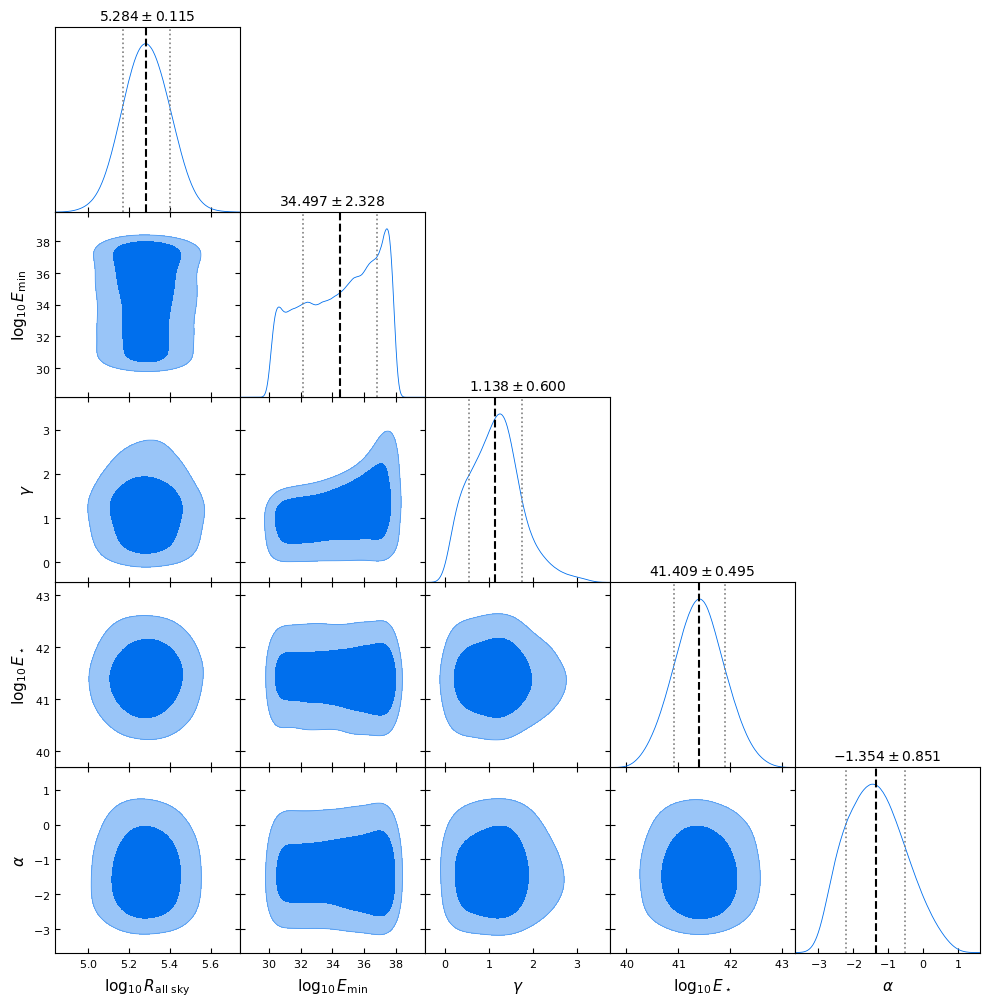

In [28]:
import numpy as np
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt("RESULT_SFR_5param40_3000_200/chain.dat") 

# Names
names = [
    "log10_R_all_sky",
    "log10_E_min_pop",
    "gamma",
    "log10_E_star",
    "alpha"
]

# FIXED LABELS (NO $ SYMBOL)
labels = [
    r"\log_{10} R_{\mathrm{all\ sky}}",
    r"\log_{10} E_{\min}",
    r"\gamma",
    r"\log_{10} E_\star",
    r"\alpha"
]

# Create samples
samples = MCSamples(samples=data, names=names, labels=labels)

# Plot
g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True)

# ---------------------------------------------------------
# ADD MEAN VALUE + SIGMA LINES + TEXT AT TOP BOUNDARY
# ---------------------------------------------------------

npar = len(names)

for i in range(npar):

    ax = g.subplots[i, i]

    # Mean and standard deviation
    mean = np.mean(data[:, i])
    sigma = np.std(data[:, i])

    # Vertical line at mean
    ax.axvline(mean, color='black', linestyle='--', linewidth=1.5)

    # Vertical lines at mean ± sigma
    ax.axvline(mean - sigma, color='gray', linestyle=':', linewidth=1.2)
    ax.axvline(mean + sigma, color='gray', linestyle=':', linewidth=1.2)

    # Write text at TOP square boundary
    ax.text(
        0.5, 1.02,
        rf"${mean:.3f} \pm {sigma:.3f}$",
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=10
    )

# plt.show()
plt.savefig("controur_results2.pdf", bbox_inches='tight')

Removed no burn in


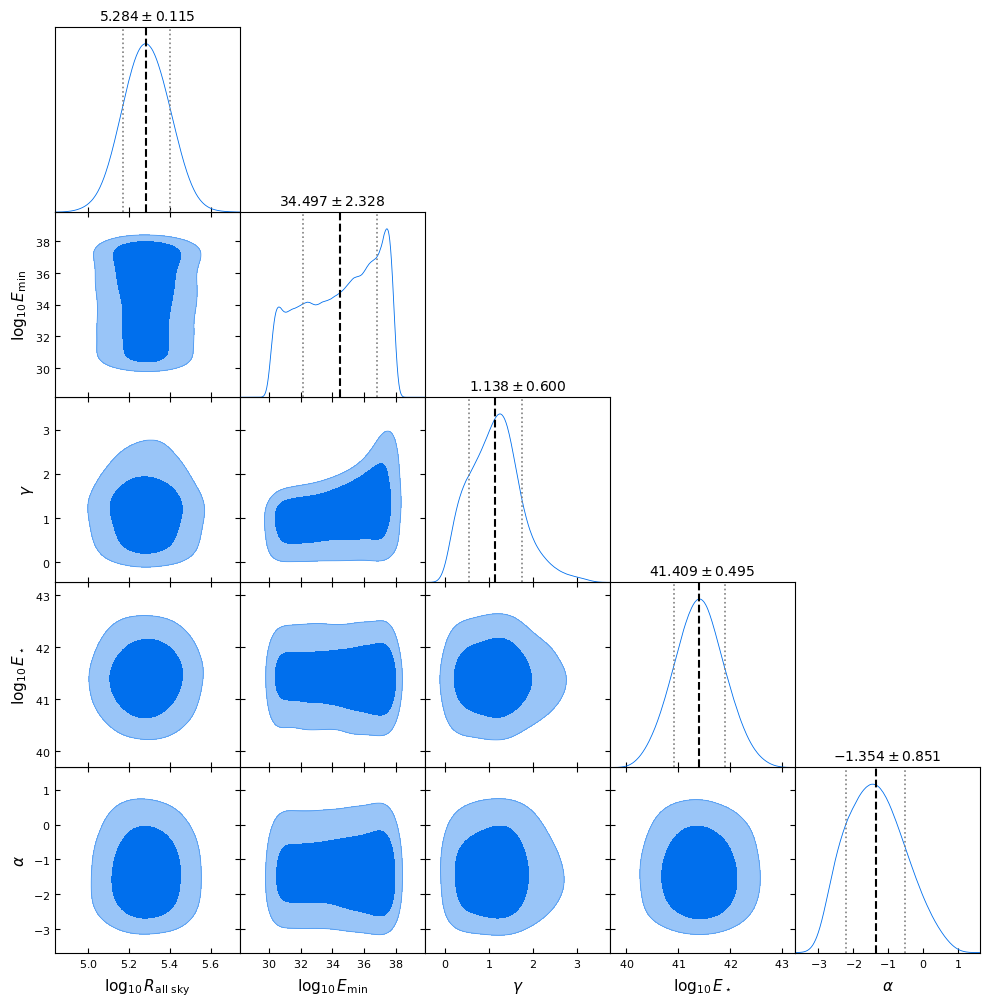

In [36]:
import numpy as np
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt("RESULT_SFR_5param40_3000_200/chain.dat") 

# Names
names = [
    "log10_R_all_sky",
    "log10_E_min_pop",
    "gamma",
    "log10_E_star",
    "alpha"
]

# FIXED LABELS (NO $ SYMBOL)
labels = [
    r"\log_{10} R_{\mathrm{all\ sky}}",
    r"\log_{10} E_{\min}",
    r"\gamma",
    r"\log_{10} E_\star",
    r"\alpha"
]

# Create samples
samples = MCSamples(samples=data, names=names, labels=labels)

# Plot
g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True)

# ---------------------------------------------------------
# ADD MEAN VALUE + SIGMA LINES + TEXT AT TOP BOUNDARY
# ---------------------------------------------------------

npar = len(names)

for i in range(npar):

    ax = g.subplots[i, i]

    # Mean and standard deviation
    mean = np.mean(data[:, i])
    sigma = np.std(data[:, i])

    # Vertical line at mean
    ax.axvline(mean, color='black', linestyle='--', linewidth=1.5)

    # Vertical lines at mean ± sigma
    ax.axvline(mean - sigma, color='gray', linestyle=':', linewidth=1.2)
    ax.axvline(mean + sigma, color='gray', linestyle=':', linewidth=1.2)

    # Write text at TOP square boundary
    ax.text(
        0.5, 1.02,
        rf"${mean:.3f} \pm {sigma:.3f}$",
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=10
    )

# plt.show()
plt.savefig("controur_results2_sm.pdf", bbox_inches='tight')

Chain shape = (30, 4000, 5)


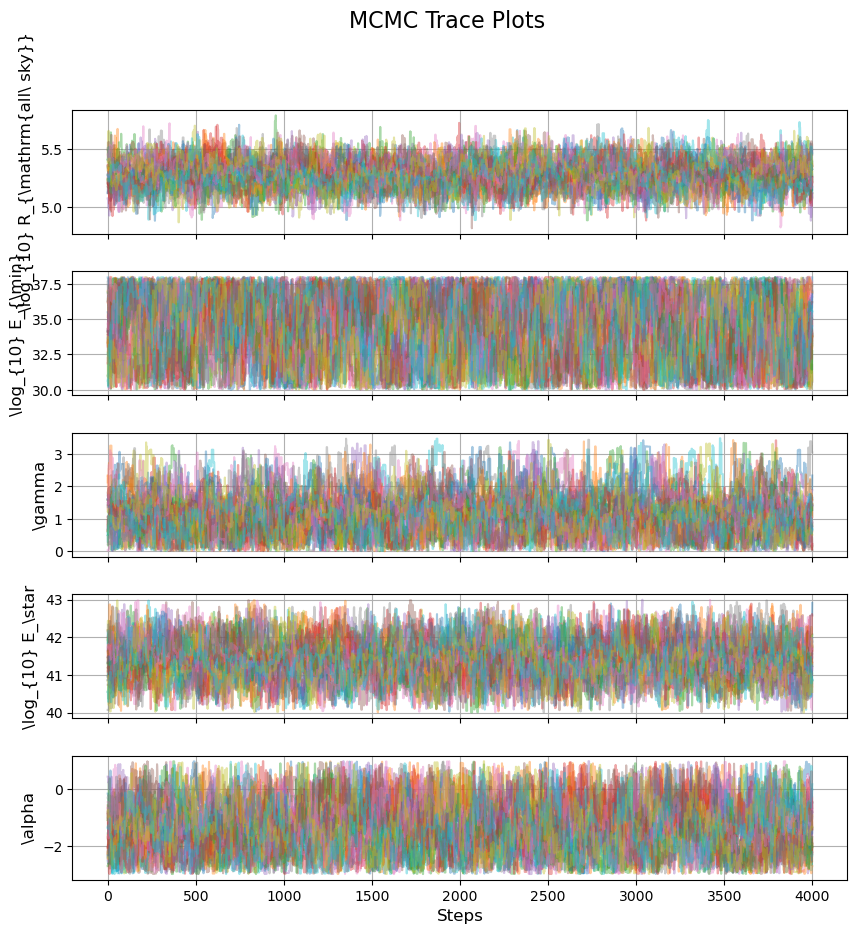

Removed no burn in


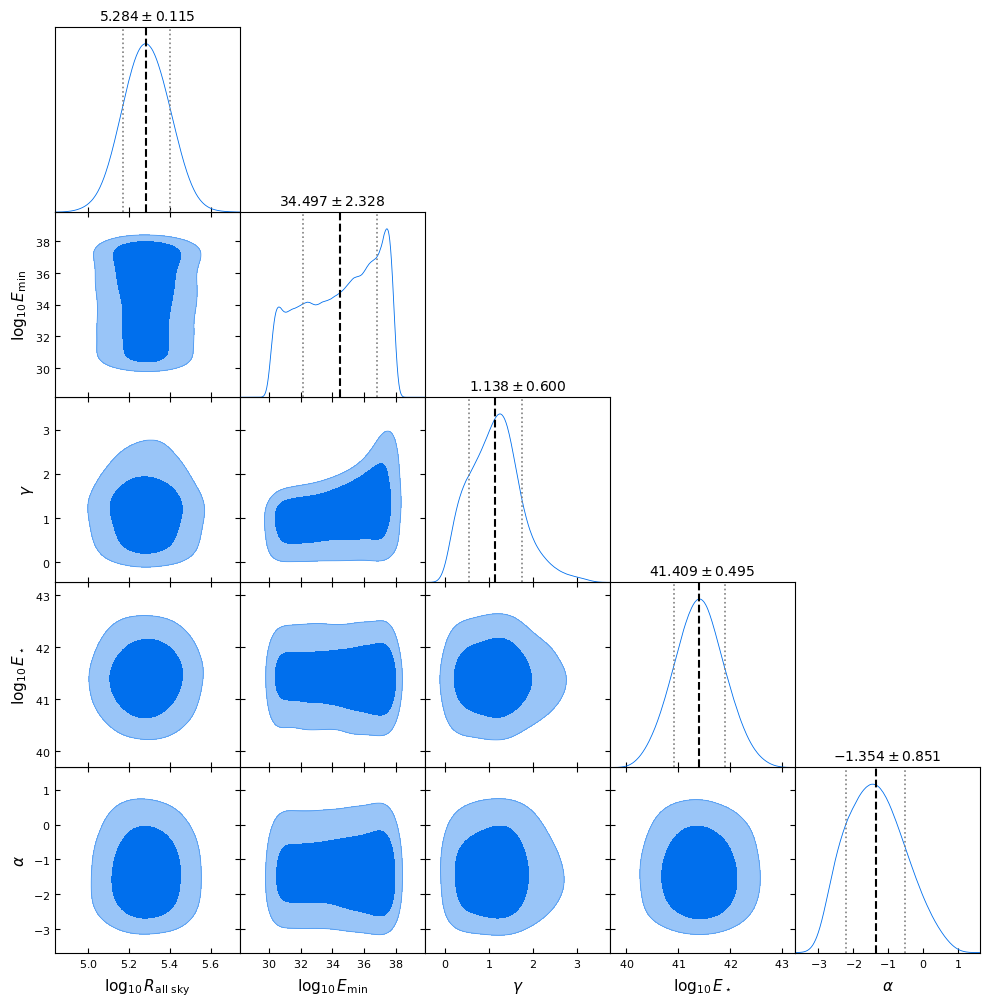

In [37]:
import numpy as np
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

# ============================================================
# LOAD DATA
# ============================================================

data = np.loadtxt("RESULT_SFR_5param40_3000_200/chain.dat")

# ============================================================
# SETTINGS
# ============================================================

ndim = 5
nwalkers = 30   # CHANGE if different

# ============================================================
# PARAMETER NAMES
# ============================================================

names = [
    "log10_R_all_sky",
    "log10_E_min_pop",
    "gamma",
    "log10_E_star",
    "alpha"
]

labels = [
    r"\log_{10} R_{\mathrm{all\ sky}}",
    r"\log_{10} E_{\min}",
    r"\gamma",
    r"\log_{10} E_\star",
    r"\alpha"
]

# ============================================================
# RESHAPE CHAIN FOR TRACE PLOTS
# ============================================================

nsteps = int(len(data) / nwalkers)

chain = data.reshape((nwalkers, nsteps, ndim))

print("Chain shape =", chain.shape)

# ============================================================
# TRACE PLOTS
# ============================================================

fig, axes = plt.subplots(ndim, 1, figsize=(10, 10), sharex=True)

for i in range(ndim):

    ax = axes[i]

    for walker in range(nwalkers):
        ax.plot(chain[walker, :, i], alpha=0.4)

    ax.set_ylabel(labels[i], fontsize=12)
    ax.grid(True)

axes[-1].set_xlabel("Steps", fontsize=12)

plt.suptitle("MCMC Trace Plots", fontsize=16)

plt.subplots_adjust(hspace=0.3)

# SAVE TRACE PLOT
plt.savefig("trace_plots.pdf", bbox_inches='tight')

plt.show()

# ============================================================
# GETDIST SAMPLES
# ============================================================

samples = MCSamples(
    samples=data,
    names=names,
    labels=labels
)

# ============================================================
# TRIANGLE / CORNER PLOT
# ============================================================

g = plots.get_subplot_plotter()

g.triangle_plot(samples, filled=True)

# ============================================================
# ADD MEAN ± SIGMA LINES
# ============================================================

npar = len(names)

for i in range(npar):

    ax = g.subplots[i, i]

    mean = np.mean(data[:, i])
    sigma = np.std(data[:, i])

    # Mean line
    ax.axvline(mean, color='black',
               linestyle='--', linewidth=1.5)

    # ± sigma lines
    ax.axvline(mean - sigma, color='gray',
               linestyle=':', linewidth=1.2)

    ax.axvline(mean + sigma, color='gray',
               linestyle=':', linewidth=1.2)

    # Text at top
    ax.text(
        0.5,
        1.02,
        rf"${mean:.3f} \pm {sigma:.3f}$",
        transform=ax.transAxes,
        ha='center',
        va='bottom',
        fontsize=10
    )

# ============================================================
# SAVE CORNER PLOT
# ============================================================

plt.savefig("contour_results2.pdf", bbox_inches='tight')

plt.show()

In [38]:
samples = sampler.get_chain()
log_prob = sampler.get_log_prob()

flat_index = np.argmax(log_prob)

step_idx, walker_idx = np.unravel_index(flat_index, log_prob.shape)

best_fit = samples[step_idx, walker_idx]

print("Maximum likelihood parameters:")
print(best_fit)
print("Maximum likelihood value is:")
print(np.max(log_prob))

Maximum likelihood parameters:
[ 5.27422382 34.24889167  1.37263158 41.38558122 -1.48194061]
Maximum likelihood value is:
-0.7456979988028846


NameError: name 'output_dir' is not defined

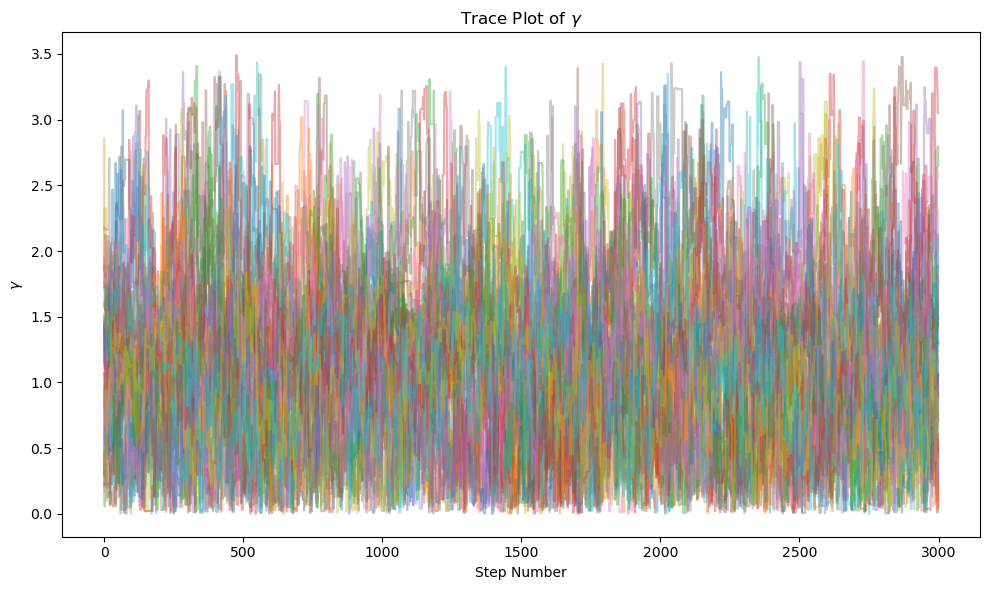

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Get chain
samples = sampler.get_chain()

# Gamma parameter index
gamma_index = 2   # change according to your parameter order

# Extract gamma chains
gamma_chain = samples[:, :, gamma_index]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(gamma_chain, alpha=0.4)

ax.set_xlabel("Step Number")
ax.set_ylabel(r"$\gamma$")
ax.set_title(r"Trace Plot of $\gamma$")

plt.tight_layout()

# Save plot
save_path = os.path.join(output_dir, "gamma_trace_plot.pdf")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

Removed no burn in


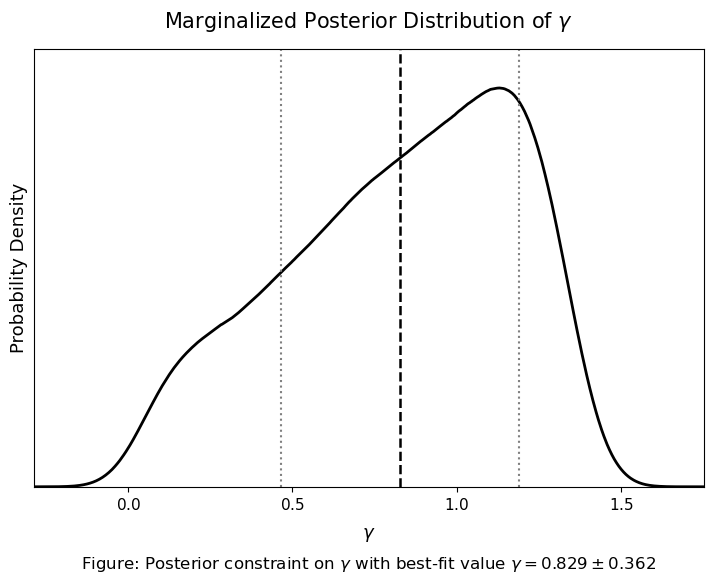

In [178]:
import numpy as np
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

data = np.loadtxt("RESULT_SM_4param35_2000_200/chain.dat")

names = [
    "log10_R_all_sky",
    "gamma",
    "log10_E_star",
    "alpha"
]

labels = [
    r"\log_{10} R_{\mathrm{all\ sky}}",
    r"\gamma",
    r"\log_{10} E_\star",
    r"\alpha"
]


samples = MCSamples(
    samples=data,
    names=names,
    labels=labels
)

g = plots.get_single_plotter(width_inch=7)

# Plot only gamma
g.plot_1d(samples, 'gamma')


gamma_samples = data[:, 1]

mean = np.mean(gamma_samples)
sigma = np.std(gamma_samples)

# Current axis
ax = plt.gca()

# Mean and sigma lines

ax.axvline(mean,
           color='black',
           linestyle='--',
           linewidth=1.8)

ax.axvline(mean - sigma,
           color='gray',
           linestyle=':',
           linewidth=1.5)

ax.axvline(mean + sigma,
           color='gray',
           linestyle=':',
           linewidth=1.5)

# Labels and title

ax.set_title(
    r"Marginalized Posterior Distribution of $\gamma$",
    fontsize=15,
    pad=15
)

ax.set_xlabel(r"$\gamma$", fontsize=13)
ax.set_ylabel("Probability Density", fontsize=13)


fig = plt.gcf()

fig.text(
    0.5,
    -0.02,
    rf"Figure: Posterior constraint on $\gamma$ "
    rf"with best-fit value $\gamma = {mean:.3f} \pm {sigma:.3f}$",
    ha='center',
    fontsize=12
)

plt.subplots_adjust(bottom=0.22)


plt.savefig(
    "gamma_marginalized_plot.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [180]:
import numpy as np
from getdist import MCSamples, plots
import matplotlib.pyplot as plt
import os

# -------------------------------------------------
# Load chain samples
# -------------------------------------------------

data = np.loadtxt("RESULT_SM_4param35_2000_200/chain.dat")

# -------------------------------------------------
# Parameter names and labels
# -------------------------------------------------

names = [
    "log10_R_all_sky",
    "gamma",
    "log10_E_star",
    "alpha"
]

labels = [
    r"\log_{10} R_{\mathrm{all\ sky}}",
    r"\gamma",
    r"\log_{10} E_\star",
    r"\alpha"
]

titles = [
    r"$\log_{10} R_{\mathrm{all\ sky}}$",
    r"$\gamma$",
    r"$\log_{10} E_\star$",
    r"$\alpha$"
]

# -------------------------------------------------
# Create output folder
# -------------------------------------------------

output_dir = "separate_marginalized_plots"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------------------------
# Create MCSamples object
# -------------------------------------------------

samples = MCSamples(
    samples=data,
    names=names,
    labels=labels
)

# -------------------------------------------------
# Loop over all parameters
# -------------------------------------------------

for i in range(len(names)):

    # Create new figure
    plt.figure(figsize=(7,5))

    # Create plotter
    g = plots.get_single_plotter(width_inch=6)

    # Plot 1D marginalized posterior
    g.plot_1d(samples, names[i])

    # Extract samples
    param_samples = data[:, i]

    # Mean and sigma
    mean = np.mean(param_samples)
    sigma = np.std(param_samples)

    # Current axis
    ax = plt.gca()

    # -------------------------------------------------
    # Mean and sigma lines
    # -------------------------------------------------

    ax.axvline(mean,
               color='black',
               linestyle='--',
               linewidth=1.8)

    ax.axvline(mean - sigma,
               color='gray',
               linestyle=':',
               linewidth=1.5)

    ax.axvline(mean + sigma,
               color='gray',
               linestyle=':',
               linewidth=1.5)

    # -------------------------------------------------
    # Title and labels
    # -------------------------------------------------

    ax.set_title(
        rf"Marginalized Posterior of {titles[i]}",
        fontsize=15,
        pad=15
    )

    ax.set_xlabel(titles[i], fontsize=13)
    ax.set_ylabel("Probability Density", fontsize=13)

    ax.tick_params(axis='both', labelsize=11)

    # -------------------------------------------------
    # Caption BELOW graph
    # -------------------------------------------------

    fig = plt.gcf()

    fig.text(
        0.5,
        -0.02,
        rf"Figure: Constraint on {titles[i]} "
        rf"with best-fit value "
        rf"${mean:.3f} \pm {sigma:.3f}$",
        ha='center',
        fontsize=12
    )

    # Adjust spacing
    plt.subplots_adjust(bottom=0.22)

    # -------------------------------------------------
    # Save plot
    # -------------------------------------------------

    save_path = os.path.join(
        output_dir,
        f"{names[i]}_marginalized.pdf"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

print("All separate marginalized plots saved successfully.")

Removed no burn in
All separate marginalized plots saved successfully.


<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

In [1]:
import numpy as np
from getdist import MCSamples, plots
import matplotlib.pyplot as plt
import os

# =================================================
# Load chain samples
# =================================================

data = np.loadtxt("RESULT_SFR_5param40_3000_200/chain.dat")

# =================================================
# Parameter names
# =================================================

names = [
    "log10_R_all_sky",
    "log10_E_min_pop",
    "gamma",
    "log10_E_star",
    "alpha"
]

# =================================================
# Parameter labels
# =================================================

labels = [
    r"\log_{10} R_{\mathrm{all\ sky}}",
    r"\log_{10} E_{\min}",
    r"\gamma",
    r"\log_{10} E_\star",
    r"\alpha"
]

# =================================================
# Plot titles
# =================================================

titles = [
    r"$\log_{10} R_{\mathrm{all\ sky}}$",
    r"$\log_{10} E_{\min}$",
    r"$\gamma$",
    r"$\log_{10} E_\star$",
    r"$\alpha$"
]

# =================================================
# Create output folder
# =================================================

output_dir = "SFRseparate_marginalized_95CI_plots_5param"
os.makedirs(output_dir, exist_ok=True)

# =================================================
# Create MCSamples object
# =================================================

samples = MCSamples(
    samples=data,
    names=names,
    labels=labels
)

# =================================================
# Loop over all parameters
# =================================================

for i in range(len(names)):

    # -------------------------------------------------
    # Create plotter
    # -------------------------------------------------

    g = plots.get_single_plotter(width_inch=7)

    # 1D marginalized posterior
    g.plot_1d(
        samples,
        names[i],
        normalized=True
    )

    ax = plt.gca()

    # -------------------------------------------------
    # Extract parameter samples
    # -------------------------------------------------

    param_samples = data[:, i]

    # -------------------------------------------------
    # Mean value
    # -------------------------------------------------

    mean = np.mean(param_samples)

    # -------------------------------------------------
    # 68% credible interval
    # -------------------------------------------------

    lower_68 = np.percentile(param_samples, 16)
    upper_68 = np.percentile(param_samples, 84)

    # -------------------------------------------------
    # 95% credible interval
    # -------------------------------------------------

    lower_95 = np.percentile(param_samples, 2.5)
    upper_95 = np.percentile(param_samples, 97.5)

    # -------------------------------------------------
    # Plot mean line
    # -------------------------------------------------

    ax.axvline(
        mean,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Mean'
    )

    # -------------------------------------------------
    # 68% shaded region
    # -------------------------------------------------

    ax.axvspan(
        lower_68,
        upper_68,
        alpha=0.45,
        color='deepskyblue',
        label='68% C.I.'
    )

    # -------------------------------------------------
    # 95% shaded region
    # -------------------------------------------------

    ax.axvspan(
        lower_95,
        upper_95,
        alpha=0.25,
        color='orange',
        label='95% C.I.'
    )

    # -------------------------------------------------
    # Labels and title
    # -------------------------------------------------

    ax.set_title(
        rf"Marginalized Posterior of {titles[i]}",
        fontsize=16,
        pad=15
    )

    ax.set_xlabel(
        titles[i],
        fontsize=14
    )

    ax.set_ylabel(
        "Probability Density",
        fontsize=14
    )

    ax.tick_params(
        axis='both',
        labelsize=12
    )

    # -------------------------------------------------
    # Legend
    # -------------------------------------------------

    ax.legend(
        fontsize=11,
        loc='best'
    )

    # -------------------------------------------------
    # Caption below graph
    # -------------------------------------------------

    fig = plt.gcf()

    fig.text(
        0.5,
        -0.07,
        rf"Figure: Marginalized posterior distribution of "
        rf"{titles[i]} with mean value "
        rf"${mean:.3f}$."
        "\n"
        rf"68\% credible interval: "
        rf"$[{lower_68:.3f},\ {upper_68:.3f}]$"
        "\n"
        rf"95\% credible interval: "
        rf"$[{lower_95:.3f},\ {upper_95:.3f}]$",
        ha='center',
        fontsize=11
    )

    # -------------------------------------------------
    # Adjust layout
    # -------------------------------------------------

    plt.subplots_adjust(
        bottom=0.30
    )

    # -------------------------------------------------
    # Save plots
    # -------------------------------------------------

    pdf_path = os.path.join(
        output_dir,
        f"{names[i]}_95CI.pdf"
    )

    png_path = os.path.join(
        output_dir,
        f"{names[i]}_95CI.png"
    )

    plt.savefig(
        pdf_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.savefig(
        png_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

# =================================================
# Done
# =================================================

print("All 5-parameter marginalized posterior plots saved successfully.")

Removed no burn in
All 5-parameter marginalized posterior plots saved successfully.
